<a href="https://colab.research.google.com/github/Shivani260/E-Commerce-Revenue-Prediction-Analysis---Final-Project/blob/main/E_Commerce_Revenue_Prediction_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Title: E-Commerce Revenue Prediction Analysis**



Task 1

Problem Definition:

E-commerce businesses generate revenue through a combination of factors such as marketing investment, website traffic, customer conversion, average order value, number of orders, returning customers, and discounts.

However, simply looking at total revenue does not explain which business factors are contributing to revenue changes. The objective of this project is to analyze historical e-commerce data, identify the major factors associated with revenue, understand business and customer behavior, and use these insights to support better business decisions.

In this project, Revenue will be calculated using:

Revenue = Orders × Average Order Value

The analysis will investigate how marketing spend, website visits, conversion rate, customer retention, discounts, and other available factors relate to revenue.

Main Objective: To analyze historical e-commerce data and identify the key factors influencing revenue, while providing data-driven insights that can help improve sales, marketing effectiveness, customer retention, and overall business performance.

Business Understanding:

Business Problem

An e-commerce business wants to understand and predict its daily revenue based on factors such as marketing spending, website visits, orders, conversion rate, discounts, customer behavior, sales channel, and economic conditions.

Revenue can change because of different business and external factors. Predicting revenue accurately can help the company make better decisions about marketing, sales planning, inventory, and business strategy.

Business Objective

The main objective of this project is to:

Analyze the factors that influence e-commerce revenue.
Identify important business and customer-related factors.
Build a machine learning model to predict revenue.
Help the business estimate future revenue based on available information.
Support better decisions related to marketing campaigns, sales channels, and customer engagement.

Dataset Selection:


* The dataset selected for this project is **E-commerce Revenue Prediction**, which contains historical e-commerce business data.

* The dataset includes information related to **marketing activities, website traffic, customer behavior, sales performance, pricing, product availability, and external economic factors**.

* **Revenue** is selected as the **target variable** because the main objective of the project is to predict the revenue generated by the e-commerce business.

* The following variables are selected as input features because they may have an impact on revenue:

  * Marketing spend
  * Website visits
  * Unique visitors
  * Conversion rate
  * Average order value
  * Number of orders
  * Returning customer rate
  * Discount rate
  * Advertisement clicks
  * Email campaigns
  * Mobile traffic percentage
  * Customer rating
  * Return rate
  * Shipping delay
  * Product availability
  * Competitor price index
  * Seasonality index
  * Economic index
  * Sales channel
  * Region

* **Date** is retained because it can provide useful time-related information. It can be transformed into features such as **year, month, day, or day of the week** during data preprocessing.

* **Record ID** is excluded from the prediction model because it is only a unique identifier for each record and does not provide meaningful information for predicting revenue.

* The selected variables will be further examined during **exploratory data analysis** to identify missing values, outliers, data types, distributions, and relationships with revenue.

* After data preprocessing and feature analysis, the relevant variables will be used to build a **machine learning model for e-commerce revenue prediction**.


**EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

uploaded = files.upload()

df = pd.read_csv(io.BytesIO(next(iter(uploaded.values()))))

print("Dataset uploaded successfully!")

Saving ecommerce_revenue_prediction.csv to ecommerce_revenue_prediction.csv
Dataset uploaded successfully!


In [ ]:
df.head()

,Record_ID,Date,Marketing_Spend,Website_Visits,Unique_Visitors,Conversion_Rate,Average_Order_Value,Orders,Returning_Customer_Rate,Discount_Rate,...,Customer_Rating,Return_Rate,Shipping_Delay_Days,Product_Availability,Competitor_Price_Index,Seasonality_Index,Economic_Index,Sales_Channel,Region,Revenue
0,REC004084,2022-01-01,222.36,912,624,2.14,38.93,132,48.91,0,...,3.98,8.67,2,84.26,97.22,1.125,98.40,Mobile App,East,7331.58
1,REC001825,2022-01-01,142.37,880,623,3.90,11.97,119,53.31,20,...,3.59,8.84,1,92.39,96.51,0.974,90.75,Marketplace,North,1688.17
2,REC005875,2022-01-01,176.37,908,640,3.29,29.93,111,24.14,20,...,4.69,5.80,1,84.94,94.70,1.063,96.73,Website,North,3535.34
3,REC002455,2022-01-01,282.25,840,654,4.19,50.39,112,39.29,0,...,4.65,9.36,0,98.62,93.98,0.973,102.19,Website,South,7489.14
4,REC004938,2022-01-02,191.24,928,646,3.41,35.08,119,51.72,15,...,3.16,7.49,1,93.02,99.23,0.955,100.73,Website,Central,5053.11


In [ ]:
df.shape

(6000, 23)

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6000
Number of columns: 23


In [ ]:
print(df.columns.tolist())

['Record_ID', 'Date', 'Marketing_Spend', 'Website_Visits', 'Unique_Visitors', 'Conversion_Rate', 'Average_Order_Value', 'Orders', 'Returning_Customer_Rate', 'Discount_Rate', 'Ad_Clicks', 'Email_Campaigns', 'Mobile_Traffic_Percent', 'Customer_Rating', 'Return_Rate', 'Shipping_Delay_Days', 'Product_Availability', 'Competitor_Price_Index', 'Seasonality_Index', 'Economic_Index', 'Sales_Channel', 'Region', 'Revenue']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Record_ID                6000 non-null   object 
 1   Date                     6000 non-null   object 
 2   Marketing_Spend          6000 non-null   float64
 3   Website_Visits           6000 non-null   int64  
 4   Unique_Visitors          6000 non-null   int64  
 5   Conversion_Rate          6000 non-null   float64
 6   Average_Order_Value      6000 non-null   float64
 7   Orders                   6000 non-null   int64  
 8   Returning_Customer_Rate  6000 non-null   float64
 9   Discount_Rate            6000 non-null   int64  
 10  Ad_Clicks                6000 non-null   int64  
 11  Email_Campaigns          6000 non-null   int64  
 12  Mobile_Traffic_Percent   6000 non-null   float64
 13  Customer_Rating          6000 non-null   float64
 14  Return_Rate             

In [ ]:
df.tail()

,Record_ID,Date,Marketing_Spend,Website_Visits,Unique_Visitors,Conversion_Rate,Average_Order_Value,Orders,Returning_Customer_Rate,Discount_Rate,...,Customer_Rating,Return_Rate,Shipping_Delay_Days,Product_Availability,Competitor_Price_Index,Seasonality_Index,Economic_Index,Sales_Channel,Region,Revenue
5995,REC001312,2025-12-31,260.20,967,679,4.33,56.58,108,16.16,0,...,3.59,7.83,1,89.27,130.50,1.092,96.45,Mobile App,North,9195.24
5996,REC001222,2025-12-31,70.79,914,650,2.83,76.35,119,17.90,20,...,3.47,7.39,0,85.31,93.20,1.074,101.95,Website,East,9599.12
5997,REC004347,2025-12-31,347.95,955,653,3.07,30.93,102,31.67,10,...,3.73,5.38,1,88.28,98.32,1.342,95.52,Mobile App,East,5338.44
5998,REC005554,2025-12-31,696.04,994,702,3.59,42.17,117,42.80,15,...,3.93,13.20,0,82.52,98.78,0.924,99.84,Website,South,4950.51
5999,REC000291,2025-12-31,168.10,909,639,2.20,73.75,109,39.86,20,...,4.33,8.80,1,81.16,112.27,0.857,100.30,Website,Central,6767.18


Check Missing Values

In [ ]:
missing_values = df.isnull().sum()

print(missing_values)

Record_ID                  0
Date                       0
Marketing_Spend            0
Website_Visits             0
Unique_Visitors            0
Conversion_Rate            0
Average_Order_Value        0
Orders                     0
Returning_Customer_Rate    0
Discount_Rate              0
Ad_Clicks                  0
Email_Campaigns            0
Mobile_Traffic_Percent     0
Customer_Rating            0
Return_Rate                0
Shipping_Delay_Days        0
Product_Availability       0
Competitor_Price_Index     0
Seasonality_Index          0
Economic_Index             0
Sales_Channel              0
Region                     0
Revenue                    0
dtype: int64


In [ ]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


Check Duplicate Records

In [ ]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
df = df.drop_duplicates()

Statistical Summary

In [ ]:
df.describe()

,Marketing_Spend,Website_Visits,Unique_Visitors,Conversion_Rate,Average_Order_Value,Orders,Returning_Customer_Rate,Discount_Rate,Ad_Clicks,Email_Campaigns,Mobile_Traffic_Percent,Customer_Rating,Return_Rate,Shipping_Delay_Days,Product_Availability,Competitor_Price_Index,Seasonality_Index,Economic_Index,Revenue
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,185.105773,900.623167,640.015000,3.820600,46.725718,115.064667,38.095882,13.027500,190.266333,7.555500,56.952018,4.085718,7.555812,1.512833,90.667285,100.075587,1.051388,100.017782,6879.639398
std,135.017081,28.871279,24.154186,1.079726,27.108174,10.300882,11.913369,8.253773,13.490728,4.594682,11.916908,0.525072,3.483995,1.241273,6.361308,11.956356,0.173792,4.988119,4442.339107
min,12.420000,800.000000,559.000000,0.800000,5.120000,85.000000,8.000000,0.000000,135.000000,0.000000,20.000000,2.080000,0.500000,0.000000,67.110000,70.000000,0.750000,79.330000,566.160000
25%,95.760000,881.000000,624.000000,3.100000,27.747500,108.000000,29.830000,5.000000,181.000000,4.000000,48.727500,3.730000,5.090000,1.000000,86.350000,92.047500,0.901000,96.667500,3889.660000
50%,150.105000,900.000000,640.000000,3.820000,40.215000,115.000000,38.055000,10.000000,190.000000,8.000000,56.965000,4.100000,7.480000,1.000000,90.980000,100.060000,1.055000,99.960000,5763.245000
75%,231.332500,920.000000,656.000000,4.550000,58.590000,122.000000,46.072500,20.000000,199.000000,11.000000,65.192500,4.470000,9.880000,2.000000,95.760000,108.465000,1.203000,103.440000,8624.672500
max,1737.110000,1009.000000,728.000000,7.730000,231.690000,163.000000,75.000000,30.000000,244.000000,15.000000,90.000000,5.000000,21.840000,7.000000,100.000000,135.000000,1.350000,120.670000,50542.530000


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
Record_ID,6000,6000,REC004687,1
Date,6000,1436,2025-06-12,13
Sales_Channel,6000,3,Website,2705
Region,6000,5,Central,1281


Check Unique Values

In [ ]:
df.nunique()

,0
Record_ID,6000
Date,1436
Marketing_Spend,5488
Website_Visits,180
Unique_Visitors,155
Conversion_Rate,573
Average_Order_Value,4186
Orders,70
Returning_Customer_Rate,3275
Discount_Rate,7


Convert Date Column

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)

datetime64[ns]


In [ ]:
print(df.nunique().sort_values())

Sales_Channel                 3
Region                        5
Discount_Rate                 7
Shipping_Delay_Days           8
Email_Campaigns              16
Orders                       70
Ad_Clicks                    93
Unique_Visitors             155
Website_Visits              180
Customer_Rating             255
Conversion_Rate             573
Seasonality_Index           601
Date                       1436
Return_Rate                1441
Economic_Index             1965
Product_Availability       2079
Returning_Customer_Rate    3275
Competitor_Price_Index     3296
Mobile_Traffic_Percent     3315
Average_Order_Value        4186
Marketing_Spend            5488
Revenue                    5984
Record_ID                  6000
dtype: int64


In [ ]:
df_original = df.copy()

df_clean = df.copy()

In [ ]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates().copy()

after = len(df_clean)

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal:", after)
print("Rows removed:", before - after)

Rows before duplicate removal: 6000
Rows after duplicate removal: 6000
Rows removed: 0


In [ ]:
for column in df_clean.columns:
    print(repr(column))

'Record_ID'
'Date'
'Marketing_Spend'
'Website_Visits'
'Unique_Visitors'
'Conversion_Rate'
'Average_Order_Value'
'Orders'
'Returning_Customer_Rate'
'Discount_Rate'
'Ad_Clicks'
'Email_Campaigns'
'Mobile_Traffic_Percent'
'Customer_Rating'
'Return_Rate'
'Shipping_Delay_Days'
'Product_Availability'
'Competitor_Price_Index'
'Seasonality_Index'
'Economic_Index'
'Sales_Channel'
'Region'
'Revenue'


In [ ]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.replace(' ', '_')
)

print(df_clean.columns.tolist())

['Record_ID', 'Date', 'Marketing_Spend', 'Website_Visits', 'Unique_Visitors', 'Conversion_Rate', 'Average_Order_Value', 'Orders', 'Returning_Customer_Rate', 'Discount_Rate', 'Ad_Clicks', 'Email_Campaigns', 'Mobile_Traffic_Percent', 'Customer_Rating', 'Return_Rate', 'Shipping_Delay_Days', 'Product_Availability', 'Competitor_Price_Index', 'Seasonality_Index', 'Economic_Index', 'Sales_Channel', 'Region', 'Revenue']


In [ ]:
categorical_columns = df_clean.select_dtypes(
    include='object'
).columns.tolist()

print("Object columns:")
print(categorical_columns)

Object columns:
['Record_ID', 'Sales_Channel', 'Region']


In [ ]:
text_columns = [
    'Record_ID',
    'Sales_Channel',
    'Region'
]

for column in text_columns:
    df_clean[column] = (
        df_clean[column]
        .astype(str)
        .str.strip()
    )

In [ ]:
print(df_clean['Sales_Channel'].value_counts(dropna=False))

Sales_Channel
Website        2705
Mobile App     2259
Marketplace    1036
Name: count, dtype: int64


In [ ]:
print(df_clean['Region'].value_counts(dropna=False))

Region
Central    1281
South      1220
East       1216
West       1169
North      1114
Name: count, dtype: int64


Check for Different Spellings or Letter Cases

In [ ]:
print(
    sorted(
        df_clean['Sales_Channel']
        .dropna()
        .unique()
    )
)

print(
    sorted(
        df_clean['Region']
        .dropna()
        .unique()
    )
)

['Marketplace', 'Mobile App', 'Website']
['Central', 'East', 'North', 'South', 'West']


Standardize Categorical Text

In [ ]:
df_clean['Sales_Channel'] = (
    df_clean['Sales_Channel']
    .str.strip()
    .str.title()
)

df_clean['Region'] = (
    df_clean['Region']
    .str.strip()
    .str.title()
)

Check Record ID Uniqueness

In [ ]:
print(
    "Total rows:",
    len(df_clean)
)

print(
    "Unique Record IDs:",
    df_clean['Record_ID'].nunique()
)

Total rows: 6000
Unique Record IDs: 6000


Check Duplicate Record IDs

In [ ]:
duplicate_ids = df_clean[
    df_clean['Record_ID'].duplicated(keep=False)
]

print("Duplicate Record IDs:")
print(duplicate_ids)

Duplicate Record IDs:
Empty DataFrame
Columns: [Record_ID, Date, Marketing_Spend, Website_Visits, Unique_Visitors, Conversion_Rate, Average_Order_Value, Orders, Returning_Customer_Rate, Discount_Rate, Ad_Clicks, Email_Campaigns, Mobile_Traffic_Percent, Customer_Rating, Return_Rate, Shipping_Delay_Days, Product_Availability, Competitor_Price_Index, Seasonality_Index, Economic_Index, Sales_Channel, Region, Revenue]
Index: []

[0 rows x 23 columns]


Check Record ID Format

In [ ]:
print(df_clean['Record_ID'].head(20))

0     REC004084
1     REC001825
2     REC005875
3     REC002455
4     REC004938
5     REC004725
6     REC001502
7     REC000309
8     REC004586
9     REC002533
10    REC001085
11    REC003879
12    REC001151
13    REC000026
14    REC001347
15    REC000720
16    REC000086
17    REC001572
18    REC000989
19    REC004189
Name: Record_ID, dtype: object


In [ ]:
valid_rec_id = (
    df_clean['Record_ID']
    .str.startswith('REC')
    .sum()
)

print("Records beginning with REC:", valid_rec_id)
print("Total records:", len(df_clean))

Records beginning with REC: 6000
Total records: 6000


Check Invalid Dates

In [ ]:
invalid_dates = df_clean['Date'].isnull().sum()

print("Invalid dates:", invalid_dates)

Invalid dates: 0


Date Range

In [ ]:
print(
    "Minimum date:",
    df_clean['Date'].min()
)

print(
    "Maximum date:",
    df_clean['Date'].max()
)

Minimum date: 2022-01-01 00:00:00
Maximum date: 2025-12-31 00:00:00


Number of Unique Dates

In [ ]:
print(
    "Unique dates:",
    df_clean['Date'].nunique()
)

Unique dates: 1436


Check Records Per Date

In [ ]:
records_per_date = (
    df_clean['Date']
    .value_counts()
    .sort_index()
)

print(records_per_date.head(20))

Date
2022-01-01    4
2022-01-02    6
2022-01-03    4
2022-01-04    4
2022-01-05    4
2022-01-06    4
2022-01-07    4
2022-01-08    5
2022-01-09    5
2022-01-10    3
2022-01-11    5
2022-01-12    3
2022-01-13    2
2022-01-14    3
2022-01-15    4
2022-01-16    1
2022-01-17    4
2022-01-18    9
2022-01-19    3
2022-01-20    6
Name: count, dtype: int64


Identify Numerical Columns

In [ ]:
numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

Numeric columns:
['Marketing_Spend', 'Website_Visits', 'Unique_Visitors', 'Conversion_Rate', 'Average_Order_Value', 'Orders', 'Returning_Customer_Rate', 'Discount_Rate', 'Ad_Clicks', 'Email_Campaigns', 'Mobile_Traffic_Percent', 'Customer_Rating', 'Return_Rate', 'Shipping_Delay_Days', 'Product_Availability', 'Competitor_Price_Index', 'Seasonality_Index', 'Economic_Index', 'Revenue']


Basic Numerical Summary

In [ ]:
numerical_summary = (
    df_clean[numeric_columns]
    .describe()
    .T
)

print(numerical_summary)

                          count         mean          std     min        25%  \
Marketing_Spend          6000.0   185.105773   135.017081   12.42    95.7600   
Website_Visits           6000.0   900.623167    28.871279  800.00   881.0000   
Unique_Visitors          6000.0   640.015000    24.154186  559.00   624.0000   
Conversion_Rate          6000.0     3.820600     1.079726    0.80     3.1000   
Average_Order_Value      6000.0    46.725718    27.108174    5.12    27.7475   
Orders                   6000.0   115.064667    10.300882   85.00   108.0000   
Returning_Customer_Rate  6000.0    38.095882    11.913369    8.00    29.8300   
Discount_Rate            6000.0    13.027500     8.253773    0.00     5.0000   
Ad_Clicks                6000.0   190.266333    13.490728  135.00   181.0000   
Email_Campaigns          6000.0     7.555500     4.594682    0.00     4.0000   
Mobile_Traffic_Percent   6000.0    56.952018    11.916908   20.00    48.7275   
Customer_Rating          6000.0     4.08

In [ ]:
additional_stats = pd.DataFrame({
    'Mean': df_clean[numeric_columns].mean(),
    'Median': df_clean[numeric_columns].median(),
    'Std': df_clean[numeric_columns].std(),
    'Variance': df_clean[numeric_columns].var(),
    'Min': df_clean[numeric_columns].min(),
    'Max': df_clean[numeric_columns].max(),
    'Skewness': df_clean[numeric_columns].skew(),
    'Kurtosis': df_clean[numeric_columns].kurt()
})

print(additional_stats)

                                Mean    Median          Std      Variance  \
Marketing_Spend           185.105773   150.105   135.017081  1.822961e+04   
Website_Visits            900.623167   900.000    28.871279  8.335508e+02   
Unique_Visitors           640.015000   640.000    24.154186  5.834247e+02   
Conversion_Rate             3.820600     3.820     1.079726  1.165808e+00   
Average_Order_Value        46.725718    40.215    27.108174  7.348531e+02   
Orders                    115.064667   115.000    10.300882  1.061082e+02   
Returning_Customer_Rate    38.095882    38.055    11.913369  1.419284e+02   
Discount_Rate              13.027500    10.000     8.253773  6.812476e+01   
Ad_Clicks                 190.266333   190.000    13.490728  1.819997e+02   
Email_Campaigns             7.555500     8.000     4.594682  2.111110e+01   
Mobile_Traffic_Percent     56.952018    56.965    11.916908  1.420127e+02   
Customer_Rating             4.085718     4.100     0.525072  2.757010e-01   

Check Negative Values

In [ ]:
for column in numeric_columns:

    negative_count = (
        df_clean[column] < 0
    ).sum()

    print(
        column,
        ":",
        negative_count,
        "negative values"
    )

Marketing_Spend : 0 negative values
Website_Visits : 0 negative values
Unique_Visitors : 0 negative values
Conversion_Rate : 0 negative values
Average_Order_Value : 0 negative values
Orders : 0 negative values
Returning_Customer_Rate : 0 negative values
Discount_Rate : 0 negative values
Ad_Clicks : 0 negative values
Email_Campaigns : 0 negative values
Mobile_Traffic_Percent : 0 negative values
Customer_Rating : 0 negative values
Return_Rate : 0 negative values
Shipping_Delay_Days : 0 negative values
Product_Availability : 0 negative values
Competitor_Price_Index : 0 negative values
Seasonality_Index : 0 negative values
Economic_Index : 0 negative values
Revenue : 0 negative values


Check Revenue Values

In [ ]:
print(
    "Minimum Revenue:",
    df_clean['Revenue'].min()
)

print(
    "Maximum Revenue:",
    df_clean['Revenue'].max()
)

print(
    "Zero Revenue Records:",
    (df_clean['Revenue'] == 0).sum()
)

print(
    "Negative Revenue Records:",
    (df_clean['Revenue'] < 0).sum()
)

Minimum Revenue: 566.16
Maximum Revenue: 50542.53
Zero Revenue Records: 0
Negative Revenue Records: 0


Marketing Spend Validation

In [ ]:
print(
    "Negative Marketing Spend:",
    (df_clean['Marketing_Spend'] < 0).sum()
)

print(
    "Zero Marketing Spend:",
    (df_clean['Marketing_Spend'] == 0).sum()
)

Negative Marketing Spend: 0
Zero Marketing Spend: 0


Website Visit Validation

In [ ]:
print(
    "Negative Website Visits:",
    (df_clean['Website_Visits'] < 0).sum()
)

print(
    "Zero Website Visits:",
    (df_clean['Website_Visits'] == 0).sum()
)

Negative Website Visits: 0
Zero Website Visits: 0


Unique Visitors vs Website Visits

In [ ]:
invalid_visitor_rows = df_clean[
    df_clean['Unique_Visitors'] >
    df_clean['Website_Visits']
]

print(
    "Rows where Unique Visitors > Website Visits:",
    len(invalid_visitor_rows)
)

Rows where Unique Visitors > Website Visits: 0


Conversion Rate Range

In [ ]:
print(
    "Minimum Conversion Rate:",
    df_clean['Conversion_Rate'].min()
)

print(
    "Maximum Conversion Rate:",
    df_clean['Conversion_Rate'].max()
)

Minimum Conversion Rate: 0.8
Maximum Conversion Rate: 7.73


Check Percentage-Type Variables

In [ ]:
percentage_columns = [
    'Conversion_Rate',
    'Returning_Customer_Rate',
    'Discount_Rate',
    'Mobile_Traffic_Percent',
    'Return_Rate'
]

for column in percentage_columns:

    print("\n", column)

    print(
        "Min:",
        df_clean[column].min()
    )

    print(
        "Max:",
        df_clean[column].max()
    )

    print(
        "Below 0:",
        (df_clean[column] < 0).sum()
    )

    print(
        "Above 100:",
        (df_clean[column] > 100).sum()
    )


 Conversion_Rate
Min: 0.8
Max: 7.73
Below 0: 0
Above 100: 0

 Returning_Customer_Rate
Min: 8.0
Max: 75.0
Below 0: 0
Above 100: 0

 Discount_Rate
Min: 0
Max: 30
Below 0: 0
Above 100: 0

 Mobile_Traffic_Percent
Min: 20.0
Max: 90.0
Below 0: 0
Above 100: 0

 Return_Rate
Min: 0.5
Max: 21.84
Below 0: 0
Above 100: 0


Customer Rating Validation

In [ ]:
print(
    "Minimum Customer Rating:",
    df_clean['Customer_Rating'].min()
)

print(
    "Maximum Customer Rating:",
    df_clean['Customer_Rating'].max()
)

print(
    "Ratings below 0:",
    (df_clean['Customer_Rating'] < 0).sum()
)

print(
    "Ratings above 5:",
    (df_clean['Customer_Rating'] > 5).sum()
)

Minimum Customer Rating: 2.08
Maximum Customer Rating: 5.0
Ratings below 0: 0
Ratings above 5: 0


Shipping Delay Validation

In [ ]:
print(
    "Minimum Shipping Delay:",
    df_clean['Shipping_Delay_Days'].min()
)

print(
    "Negative Shipping Delay:",
    (df_clean['Shipping_Delay_Days'] < 0).sum()
)

Minimum Shipping Delay: 0
Negative Shipping Delay: 0


Order Validation

In [ ]:
print(
    "Minimum Orders:",
    df_clean['Orders'].min()
)

print(
    "Zero Order Records:",
    (df_clean['Orders'] == 0).sum()
)

print(
    "Negative Orders:",
    (df_clean['Orders'] < 0).sum()
)

Minimum Orders: 85
Zero Order Records: 0
Negative Orders: 0


Function to Detect Outliers

In [ ]:
def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return (
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        len(outliers)
    )

Detect Outliers for Every Numeric Column

In [ ]:
outlier_results = []

for column in numeric_columns:

    if column == 'Record_ID':
        continue

    Q1, Q3, IQR, lower, upper, count = (
        detect_outliers_iqr(
            df_clean,
            column
        )
    )

    outlier_results.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower,
        'Upper_Bound': upper,
        'Outlier_Count': count,
        'Outlier_Percentage':
            (count / len(df_clean)) * 100
    })

Create Outlier Summary

In [ ]:
outlier_summary = pd.DataFrame(
    outlier_results
)

outlier_summary = (
    outlier_summary
    .sort_values(
        'Outlier_Count',
        ascending=False
    )
)

print(outlier_summary)

                     Column         Q1         Q3        IQR  Lower_Bound  \
13      Shipping_Delay_Days     1.0000     2.0000     1.0000     -0.50000   
0           Marketing_Spend    95.7600   231.3325   135.5725   -107.59875   
18                  Revenue  3889.6600  8624.6725  4735.0125  -3212.85875   
4       Average_Order_Value    27.7475    58.5900    30.8425    -18.51625   
2           Unique_Visitors   624.0000   656.0000    32.0000    576.00000   
8                 Ad_Clicks   181.0000   199.0000    18.0000    154.00000   
3           Conversion_Rate     3.1000     4.5500     1.4500      0.92500   
1            Website_Visits   881.0000   920.0000    39.0000    822.50000   
17           Economic_Index    96.6675   103.4400     6.7725     86.50875   
5                    Orders   108.0000   122.0000    14.0000     87.00000   
6   Returning_Customer_Rate    29.8300    46.0725    16.2425      5.46625   
14     Product_Availability    86.3500    95.7600     9.4100     72.23500   

View Outliers for Revenue

In [ ]:
Q1 = df_clean['Revenue'].quantile(0.25)
Q3 = df_clean['Revenue'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

revenue_outliers = df_clean[
    (df_clean['Revenue'] < lower) |
    (df_clean['Revenue'] > upper)
]

print(
    "Revenue lower bound:",
    lower
)

print(
    "Revenue upper bound:",
    upper
)

print(
    "Number of Revenue outliers:",
    len(revenue_outliers)
)

print(
    revenue_outliers[
        [
            'Record_ID',
            'Revenue',
            'Orders',
            'Average_Order_Value'
        ]
    ].head(20)
)

Revenue lower bound: -3212.8587500000012
Revenue upper bound: 15727.191250000002
Number of Revenue outliers: 271
     Record_ID   Revenue  Orders  Average_Order_Value
44   REC003700  23717.43     118               148.13
83   REC002739  28139.10     127               142.02
101  REC003625  24007.36     114               215.68
132  REC000576  19640.38     113                96.57
200  REC005108  26580.57     107               230.51
205  REC004719  19291.72     114               126.22
211  REC001349  18659.16     122               125.94
305  REC002688  21470.25     117               126.81
306  REC003619  23888.50     120               132.91
335  REC005592  17679.76     122                76.62
396  REC001277  19580.21     122               122.70
421  REC003171  18005.36     114               114.27
429  REC000043  16016.10     125               120.58
468  REC003427  24341.61     119               176.80
482  REC005414  16076.86     120               124.75
505  REC001070  16347.1

Extract Date Features

In [ ]:
df_clean['Year'] = (
    df_clean['Date'].dt.year
)

df_clean['Month'] = (
    df_clean['Date'].dt.month
)

df_clean['Month_Name'] = (
    df_clean['Date'].dt.month_name()
)

df_clean['Day'] = (
    df_clean['Date'].dt.day
)

df_clean['Day_of_Week'] = (
    df_clean['Date'].dt.day_name()
)

df_clean['Day_of_Week_Num'] = (
    df_clean['Date'].dt.dayofweek
)

df_clean['Quarter'] = (
    df_clean['Date'].dt.quarter
)

df_clean['Week_of_Year'] = (
    df_clean['Date']
    .dt.isocalendar()
    .week
    .astype(int)
)

Create Month Start/End Features

In [ ]:
df_clean['Is_Month_Start'] = (
    df_clean['Date']
    .dt.is_month_start
    .astype(int)
)

df_clean['Is_Month_End'] = (
    df_clean['Date']
    .dt.is_month_end
    .astype(int)
)

Create Year-Month Variable

In [ ]:
df_clean['Year_Month'] = (
    df_clean['Date']
    .dt.to_period('M')
    .astype(str)
)

FEATURE ENGINEERING

Revenue Per Order

In [ ]:
df_clean['Revenue_Per_Order'] = np.where(
    df_clean['Orders'] > 0,
    df_clean['Revenue'] / df_clean['Orders'],
    0
)

Marketing Efficiency

In [ ]:
df_clean['Revenue_Per_Marketing_Dollar'] = np.where(
    df_clean['Marketing_Spend'] > 0,
    df_clean['Revenue'] /
    df_clean['Marketing_Spend'],
    0
)

Marketing Cost Per Order

In [ ]:
df_clean['Marketing_Cost_Per_Order'] = np.where(
    df_clean['Orders'] > 0,
    df_clean['Marketing_Spend'] /
    df_clean['Orders'],
    0
)

Marketing Cost Per Visitor

In [ ]:
df_clean['Marketing_Cost_Per_Visitor'] = np.where(
    df_clean['Website_Visits'] > 0,
    df_clean['Marketing_Spend'] /
    df_clean['Website_Visits'],
    0
)

Visitor-to-Order Rate

In [ ]:
df_clean['Visitor_Order_Rate'] = np.where(
    df_clean['Website_Visits'] > 0,
    (
        df_clean['Orders'] /
        df_clean['Website_Visits']
    ) * 100,
    0
)

Unique Visitor Ratio

In [ ]:
df_clean['Unique_Visitor_Ratio'] = np.where(
    df_clean['Website_Visits'] > 0,
    (
        df_clean['Unique_Visitors'] /
        df_clean['Website_Visits']
    ) * 100,
    0
)

Ad Click Rate

In [ ]:
df_clean['Ad_Click_Rate'] = np.where(
    df_clean['Website_Visits'] > 0,
    (
        df_clean['Ad_Clicks'] /
        df_clean['Website_Visits']
    ) * 100,
    0
)

Orders Per Ad Click

In [ ]:
df_clean['Orders_Per_Ad_Click'] = np.where(
    df_clean['Ad_Clicks'] > 0,
    df_clean['Orders'] /
    df_clean['Ad_Clicks'],
    0
)

Revenue Per Website Visit

In [ ]:
df_clean['Revenue_Per_Visit'] = np.where(
    df_clean['Website_Visits'] > 0,
    df_clean['Revenue'] /
    df_clean['Website_Visits'],
    0
)

Revenue Per Unique Visitor

In [ ]:
df_clean['Revenue_Per_Unique_Visitor'] = np.where(
    df_clean['Unique_Visitors'] > 0,
    df_clean['Revenue'] /
    df_clean['Unique_Visitors'],
    0
)

Estimated Returning Customer Contribution

In [ ]:
df_clean['Estimated_Returning_Orders'] = (
    df_clean['Orders'] *
    df_clean['Returning_Customer_Rate'] /
    100
)

Estimated New Customer Orders

In [ ]:
df_clean['Estimated_New_Customer_Orders'] = (
    df_clean['Orders'] -
    df_clean['Estimated_Returning_Orders']
)

Discounted Order Value Estimate

In [ ]:
df_clean['Discount_Adjusted_Order_Value'] = (
    df_clean['Average_Order_Value'] *
    (
        1 -
        df_clean['Discount_Rate'] / 100
    )
)

Potential Gross Order Value

In [ ]:
df_clean['Potential_Order_Value'] = (
    df_clean['Orders'] *
    df_clean['Average_Order_Value']
)

Revenue Gap

In [ ]:
df_clean['Revenue_Gap'] = (
    df_clean['Revenue'] -
    df_clean['Potential_Order_Value']
)

Availability-Risk Feature

In [ ]:
df_clean['Availability_Risk'] = (
    100 -
    df_clean['Product_Availability']
)

Shipping Performance Category

In [ ]:
df_clean['Shipping_Performance'] = pd.cut(
    df_clean['Shipping_Delay_Days'],
    bins=[
        -np.inf,
        1,
        3,
        5,
        np.inf
    ],
    labels=[
        'Fast',
        'Moderate',
        'Delayed',
        'Highly Delayed'
    ]
)

Customer Rating Category

In [ ]:
df_clean['Rating_Category'] = pd.cut(
    df_clean['Customer_Rating'],
    bins=[
        0,
        2,
        3,
        4,
        5
    ],
    labels=[
        'Poor',
        'Average',
        'Good',
        'Excellent'
    ],
    include_lowest=True
)

Discount Category

In [ ]:
df_clean['Discount_Category'] = pd.cut(
    df_clean['Discount_Rate'],
    bins=[
        -1,
        0,
        10,
        20,
        100
    ],
    labels=[
        'No Discount',
        'Low Discount',
        'Medium Discount',
        'High Discount'
    ]
)

Marketing Spend Category

In [ ]:
df_clean['Marketing_Spend_Category'] = pd.qcut(
    df_clean['Marketing_Spend'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

Revenue Category

In [ ]:
df_clean['Revenue_Category'] = pd.qcut(
    df_clean['Revenue'],
    q=4,
    labels=[
        'Low Revenue',
        'Medium Revenue',
        'High Revenue',
        'Very High Revenue'
    ]
)

FINAL EDA

Updated Dataset Shape

In [ ]:
print(
    "Dataset shape after feature engineering:",
    df_clean.shape
)

Dataset shape after feature engineering: (6000, 55)


Updated Columns

In [ ]:
for i, column in enumerate(
    df_clean.columns,
    start=1
):
    print(i, column)

1 Record_ID
2 Date
3 Marketing_Spend
4 Website_Visits
5 Unique_Visitors
6 Conversion_Rate
7 Average_Order_Value
8 Orders
9 Returning_Customer_Rate
10 Discount_Rate
11 Ad_Clicks
12 Email_Campaigns
13 Mobile_Traffic_Percent
14 Customer_Rating
15 Return_Rate
16 Shipping_Delay_Days
17 Product_Availability
18 Competitor_Price_Index
19 Seasonality_Index
20 Economic_Index
21 Sales_Channel
22 Region
23 Revenue
24 Year
25 Month
26 Month_Name
27 Day
28 Day_of_Week
29 Day_of_Week_Num
30 Quarter
31 Week_of_Year
32 Is_Month_Start
33 Is_Month_End
34 Year_Month
35 Revenue_Per_Order
36 Revenue_Per_Marketing_Dollar
37 Marketing_Cost_Per_Order
38 Marketing_Cost_Per_Visitor
39 Visitor_Order_Rate
40 Unique_Visitor_Ratio
41 Ad_Click_Rate
42 Orders_Per_Ad_Click
43 Revenue_Per_Visit
44 Revenue_Per_Unique_Visitor
45 Estimated_Returning_Orders
46 Estimated_New_Customer_Orders
47 Discount_Adjusted_Order_Value
48 Potential_Order_Value
49 Revenue_Gap
50 Availability_Risk
51 Shipping_Performance
52 Rating_Category

TARGET VARIABLE ANALYSIS

Revenue Summary

In [ ]:
revenue_summary = df_clean['Revenue'].describe()

print(revenue_summary)

count     6000.000000
mean      6879.639398
std       4442.339107
min        566.160000
25%       3889.660000
50%       5763.245000
75%       8624.672500
max      50542.530000
Name: Revenue, dtype: float64


Revenue Mean and Median

In [ ]:
print(
    "Mean Revenue:",
    df_clean['Revenue'].mean()
)

print(
    "Median Revenue:",
    df_clean['Revenue'].median()
)

print(
    "Standard Deviation:",
    df_clean['Revenue'].std()
)

print(
    "Variance:",
    df_clean['Revenue'].var()
)

Mean Revenue: 6879.639398333334
Median Revenue: 5763.245
Standard Deviation: 4442.339107229835
Variance: 19734376.743623566


Revenue Skewness

In [ ]:
print(
    "Revenue Skewness:",
    df_clean['Revenue'].skew()
)

print(
    "Revenue Kurtosis:",
    df_clean['Revenue'].kurt()
)

Revenue Skewness: 2.0214740176026242
Revenue Kurtosis: 7.004076209596788


Revenue Percentiles

In [ ]:
revenue_percentiles = (
    df_clean['Revenue']
    .quantile([
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ])
)

print(revenue_percentiles)

0.01     1464.2902
0.05     2134.0765
0.10     2655.6760
0.25     3889.6600
0.50     5763.2450
0.75     8624.6725
0.90    12538.2800
0.95    15295.5175
0.99    23035.2270
Name: Revenue, dtype: float64


CATEGORICAL EDA

Sales Channel Distribution

In [ ]:
sales_channel_counts = (
    df_clean['Sales_Channel']
    .value_counts()
)

sales_channel_percentage = (
    df_clean['Sales_Channel']
    .value_counts(
        normalize=True
    ) * 100
)

sales_channel_summary = pd.DataFrame({
    'Count':
        sales_channel_counts,
    'Percentage':
        sales_channel_percentage
})

print(sales_channel_summary)

               Count  Percentage
Sales_Channel                   
Website         2705   45.083333
Mobile App      2259   37.650000
Marketplace     1036   17.266667


Region Distribution

In [ ]:
region_summary = pd.DataFrame({
    'Count':
        df_clean['Region']
        .value_counts(),

    'Percentage':
        df_clean['Region']
        .value_counts(
            normalize=True
        ) * 100
})

print(region_summary)

         Count  Percentage
Region                    
Central   1281   21.350000
South     1220   20.333333
East      1216   20.266667
West      1169   19.483333
North     1114   18.566667


GROUPED REVENUE ANALYSIS

Revenue by Sales Channel

In [ ]:
channel_analysis = (
    df_clean
    .groupby(
        'Sales_Channel',
        observed=True
    )
    .agg(
        Records=('Revenue', 'size'),
        Total_Revenue=('Revenue', 'sum'),
        Average_Revenue=('Revenue', 'mean'),
        Median_Revenue=('Revenue', 'median'),
        Min_Revenue=('Revenue', 'min'),
        Max_Revenue=('Revenue', 'max'),
        Revenue_Std=('Revenue', 'std')
    )
    .sort_values(
        'Average_Revenue',
        ascending=False
    )
)

print(channel_analysis)

               Records  Total_Revenue  Average_Revenue  Median_Revenue  \
Sales_Channel                                                            
Mobile App        2259    16378880.06      7250.500248        6120.580   
Website           2705    18483636.92      6833.137494        5762.850   
Marketplace       1036     6415319.41      6192.393253        5101.215   

               Min_Revenue  Max_Revenue  Revenue_Std  
Sales_Channel                                         
Mobile App          964.12     50542.53  4654.034025  
Website             751.98     36107.19  4322.760913  
Marketplace         566.16     31398.38  4187.012644  


Revenue by Region

In [ ]:
region_analysis = (
    df_clean
    .groupby(
        'Region',
        observed=True
    )
    .agg(
        Records=('Revenue', 'size'),
        Total_Revenue=('Revenue', 'sum'),
        Average_Revenue=('Revenue', 'mean'),
        Median_Revenue=('Revenue', 'median'),
        Average_Orders=('Orders', 'mean'),
        Average_Marketing=('Marketing_Spend', 'mean')
    )
    .sort_values(
        'Average_Revenue',
        ascending=False
    )
)

print(region_analysis)

         Records  Total_Revenue  Average_Revenue  Median_Revenue  \
Region                                                             
West        1169     8546884.81      7311.278708        6023.810   
North       1114     7758190.75      6964.264587        5807.225   
East        1216     8280630.44      6809.728980        5714.305   
Central     1281     8637324.03      6742.641710        5805.550   
South       1220     8054806.36      6602.300295        5526.500   

         Average_Orders  Average_Marketing  
Region                                      
West         115.005133         184.750992  
North        115.785458         180.217316  
East         114.876645         184.519161  
Central      114.733021         187.434645  
South        114.999180         188.048820  


Revenue by Sales Channel and Region

In [ ]:
channel_region_analysis = (
    df_clean
    .groupby(
        [
            'Sales_Channel',
            'Region'
        ],
        observed=True
    )
    .agg(
        Count=('Revenue', 'size'),
        Revenue=('Revenue', 'mean'),
        Orders=('Orders', 'mean'),
        Marketing_Spend=(
            'Marketing_Spend',
            'mean'
        )
    )
    .round(2)
)

print(channel_region_analysis)

                       Count  Revenue  Orders  Marketing_Spend
Sales_Channel Region                                          
Marketplace   Central    204  6252.47  114.90           191.98
              East       196  6106.69  115.39           174.32
              North      197  6220.85  116.80           187.89
              South      229  6003.83  115.89           181.56
              West       210  6392.96  115.28           190.91
Mobile App    Central    495  6842.93  114.68           176.88
              East       450  7146.64  114.41           185.26
              North      436  7493.22  115.94           183.85
              South      455  6855.86  114.65           187.93
              West       423  8012.25  115.62           179.39
Website       Central    582  6829.16  114.72           194.82
              East       570  6785.49  115.07           187.44
              North      481  6789.27  115.23           173.78
              South      536  6642.75  114.92          

TIME-BASED EDA

Revenue by Year

In [ ]:
yearly_analysis = (
    df_clean
    .groupby('Year')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Average_Revenue=('Revenue', 'mean'),
        Total_Orders=('Orders', 'sum'),
        Average_Marketing=(
            'Marketing_Spend',
            'mean'
        )
    )
)

print(yearly_analysis)

      Total_Revenue  Average_Revenue  Total_Orders  Average_Marketing
Year                                                                 
2022    10229985.37      6806.377492        173314         181.730572
2023    10215940.78      6912.003234        169709         184.665927
2024    10624289.69      7035.953437        173221         186.930258
2025    10207620.55      6764.493406        174144         187.072671


Revenue by Month

In [ ]:
monthly_analysis = (
    df_clean
    .groupby('Month')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Average_Revenue=('Revenue', 'mean'),
        Average_Orders=('Orders', 'mean')
    )
)

print(monthly_analysis)

       Total_Revenue  Average_Revenue  Average_Orders
Month                                                
1         3308084.27      6820.792309      114.977320
2         3204725.28      6690.449436      114.745303
3         3445598.99      6905.007996      114.831663
4         3274050.18      6907.278861      115.048523
5         3834609.30      6972.016909      114.249091
6         3701268.33      7076.994895      115.978967
7         3294718.81      6737.666278      114.664622
8         3450068.76      6927.848916      115.056225
9         3223662.35      6829.793114      115.167373
10        3671471.18      7101.491644      115.470019
11        3508740.55      6961.786806      115.067460
12        3360838.39      6589.879196      115.515686


Revenue by Month Name

In [ ]:
month_name_analysis = (
    df_clean
    .groupby(
        'Month_Name'
    )
    .agg(
        Count=('Revenue', 'size'),
        Average_Revenue=('Revenue', 'mean'),
        Total_Revenue=('Revenue', 'sum')
    )
)

print(month_name_analysis)

            Count  Average_Revenue  Total_Revenue
Month_Name                                       
April         474      6907.278861     3274050.18
August        498      6927.848916     3450068.76
December      510      6589.879196     3360838.39
February      479      6690.449436     3204725.28
January       485      6820.792309     3308084.27
July          489      6737.666278     3294718.81
June          523      7076.994895     3701268.33
March         499      6905.007996     3445598.99
May           550      6972.016909     3834609.30
November      504      6961.786806     3508740.55
October       517      7101.491644     3671471.18
September     472      6829.793114     3223662.35


Revenue by Quarter

In [ ]:
quarter_analysis = (
    df_clean
    .groupby('Quarter')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Average_Revenue=('Revenue', 'mean'),
        Average_Orders=('Orders', 'mean')
    )
)

print(quarter_analysis)

         Total_Revenue  Average_Revenue  Average_Orders
Quarter                                                
1           9958408.54      6806.841107      114.851675
2          10809927.81      6987.671500      115.078862
3           9968449.92      6832.385141      114.960932
4          10541050.12      6885.075193      115.352711


Revenue by Day of Week

In [ ]:
day_analysis = (
    df_clean
    .groupby(
        'Day_of_Week'
    )
    .agg(
        Count=('Revenue', 'size'),
        Average_Revenue=('Revenue', 'mean'),
        Average_Orders=('Orders', 'mean')
    )
    .sort_values(
        'Average_Revenue',
        ascending=False
    )
)

print(day_analysis)

             Count  Average_Revenue  Average_Orders
Day_of_Week                                        
Sunday         835      7057.027485      115.233533
Saturday       815      6960.552147      114.915337
Friday         897      6896.889476      115.313266
Wednesday      850      6878.604671      114.523529
Thursday       869      6828.076479      114.781358
Tuesday        872      6781.717683      115.605505
Monday         862      6765.415696      115.055684


Weekend vs Weekday

In [ ]:
# Make sure Date is in datetime format
df_clean['Date'] = pd.to_datetime(
    df_clean['Date'],
    errors='coerce'
)

# Create day of week number
df_clean['Day_of_Week_Num'] = df_clean['Date'].dt.dayofweek


In [ ]:
# Create weekend indicator
# 0 = Weekday
# 1 = Weekend
df_clean['Is_Weekend'] = (
    df_clean['Day_of_Week_Num'].isin([5, 6])
    .astype(int)
)

# Check that the column was created
print(df_clean[['Date', 'Day_of_Week_Num', 'Is_Weekend']].head(10))

        Date  Day_of_Week_Num  Is_Weekend
0 2022-01-01                5           1
1 2022-01-01                5           1
2 2022-01-01                5           1
3 2022-01-01                5           1
4 2022-01-02                6           1
5 2022-01-02                6           1
6 2022-01-02                6           1
7 2022-01-02                6           1
8 2022-01-02                6           1
9 2022-01-02                6           1


In [ ]:
weekend_analysis = (
    df_clean
    .groupby('Is_Weekend')
    .agg(
        Records=('Revenue', 'size'),
        Average_Revenue=('Revenue', 'mean'),
        Total_Revenue=('Revenue', 'sum'),
        Average_Orders=('Orders', 'mean')
    )
)

print(weekend_analysis)

            Records  Average_Revenue  Total_Revenue  Average_Orders
Is_Weekend                                                         
0              4350      6830.429526    29712368.44      115.060230
1              1650      7009.374515    11565467.95      115.076364


BUSINESS FEATURE ANALYSIS

Revenue by Discount Category


In [ ]:
discount_analysis = (
    df_clean
    .groupby(
        'Discount_Category',
        observed=True
    )
    .agg(
        Count=('Revenue', 'size'),
        Average_Revenue=('Revenue', 'mean'),
        Average_Orders=('Orders', 'mean'),
        Average_Order_Value=(
            'Average_Order_Value',
            'mean'
        )
    )
)

print(discount_analysis)

                   Count  Average_Revenue  Average_Orders  Average_Order_Value
Discount_Category                                                             
No Discount          669      7101.902212      115.112108            47.600284
Low Discount        2362      6843.517058      115.226503            46.067701
Medium Discount     2067      6847.344533      114.807934            46.800227
High Discount        902      6883.387328      115.194013            47.629424


Revenue by Marketing Spend Category

In [ ]:
marketing_category_analysis = (
    df_clean
    .groupby(
        'Marketing_Spend_Category',
        observed=True
    )
    .agg(
        Records=('Revenue', 'size'),
        Average_Marketing=(
            'Marketing_Spend',
            'mean'
        ),
        Average_Revenue=('Revenue', 'mean'),
        Average_Orders=('Orders', 'mean')
    )
)

print(marketing_category_analysis)

                          Records  Average_Marketing  Average_Revenue  \
Marketing_Spend_Category                                                
Low                          1503          67.857931      6895.893806   
Medium                       1497         121.483353      6701.731149   
High                         1500         186.471147      7016.561400   
Very High                    1500         364.717913      6903.982913   

                          Average_Orders  
Marketing_Spend_Category                  
Low                           115.170326  
Medium                        115.078156  
High                          114.872000  
Very High                     115.138000  


Revenue by Customer Rating Category

In [ ]:
rating_analysis = (
    df_clean
    .groupby(
        'Rating_Category',
        observed=True
    )
    .agg(
        Records=('Revenue', 'size'),
        Average_Revenue=('Revenue', 'mean'),
        Average_Orders=('Orders', 'mean'),
        Average_Return_Rate=(
            'Return_Rate',
            'mean'
        )
    )
)

print(rating_analysis)

                 Records  Average_Revenue  Average_Orders  Average_Return_Rate
Rating_Category                                                               
Average              142      7429.763380      115.718310             7.381056
Good                2447      6865.951067      115.172456             7.529877
Excellent           3411      6866.557529      114.960129             7.581692


Revenue by Shipping Performance

In [ ]:
shipping_analysis = (
    df_clean
    .groupby(
        'Shipping_Performance',
        observed=True
    )
    .agg(
        Records=('Revenue', 'size'),
        Average_Revenue=('Revenue', 'mean'),
        Average_Rating=(
            'Customer_Rating',
            'mean'
        ),
        Average_Return_Rate=(
            'Return_Rate',
            'mean'
        )
    )
)

print(shipping_analysis)

                      Records  Average_Revenue  Average_Rating  \
Shipping_Performance                                             
Fast                     3358      6949.714223        4.086775   
Moderate                 2220      6848.964536        4.089419   
Delayed                   385      6537.726779        4.054286   
Highly Delayed             37      5918.106757        4.094865   

                      Average_Return_Rate  
Shipping_Performance                       
Fast                             7.562906  
Moderate                         7.587865  
Delayed                          7.416519  
Highly Delayed                   6.438108  


CORRELATION ANALYSIS

Recreate Numeric Column List

In [ ]:
numeric_df = df_clean.select_dtypes(
    include=np.number
)

Correlation Matrix

In [ ]:
correlation_matrix = numeric_df.corr()

print(correlation_matrix.round(3))

                               Marketing_Spend  Website_Visits  \
Marketing_Spend                          1.000           0.004   
Website_Visits                           0.004           1.000   
Unique_Visitors                         -0.007           0.011   
Conversion_Rate                         -0.000           0.002   
Average_Order_Value                      0.007          -0.002   
Orders                                  -0.003           0.004   
Returning_Customer_Rate                 -0.014          -0.002   
Discount_Rate                           -0.026          -0.003   
Ad_Clicks                                0.023           0.004   
Email_Campaigns                         -0.007           0.013   
Mobile_Traffic_Percent                  -0.005          -0.005   
Customer_Rating                         -0.008          -0.000   
Return_Rate                              0.002           0.001   
Shipping_Delay_Days                      0.002          -0.006   
Product_Av

Correlation With Revenue

In [ ]:
revenue_correlations = (
    correlation_matrix['Revenue']
    .drop('Revenue')
    .sort_values(
        ascending=False
    )
)

print(revenue_correlations)

Revenue_Per_Visit                0.998371
Revenue_Per_Unique_Visitor       0.997616
Revenue_Per_Order                0.985913
Potential_Order_Value            0.922653
Average_Order_Value              0.906231
Discount_Adjusted_Order_Value    0.893239
Revenue_Gap                      0.774683
Revenue_Per_Marketing_Dollar     0.587962
Seasonality_Index                0.247308
Orders                           0.151443
Visitor_Order_Rate               0.143262
Orders_Per_Ad_Click              0.112180
Product_Availability             0.101135
Estimated_Returning_Orders       0.070018
Conversion_Rate                  0.044156
Estimated_New_Customer_Orders    0.036672
Returning_Customer_Rate          0.028500
Day_of_Week_Num                  0.019961
Is_Weekend                       0.017988
Marketing_Cost_Per_Visitor       0.014195
Marketing_Spend                  0.013315
Email_Campaigns                  0.012385
Ad_Click_Rate                    0.011758
Ad_Clicks                        0

Absolute Correlation With Revenue

In [ ]:
absolute_revenue_correlation = (
    revenue_correlations
    .abs()
    .sort_values(
        ascending=False
    )
)

print(absolute_revenue_correlation)

Revenue_Per_Visit                0.998371
Revenue_Per_Unique_Visitor       0.997616
Revenue_Per_Order                0.985913
Potential_Order_Value            0.922653
Average_Order_Value              0.906231
Discount_Adjusted_Order_Value    0.893239
Revenue_Gap                      0.774683
Revenue_Per_Marketing_Dollar     0.587962
Seasonality_Index                0.247308
Orders                           0.151443
Visitor_Order_Rate               0.143262
Orders_Per_Ad_Click              0.112180
Availability_Risk                0.101135
Product_Availability             0.101135
Estimated_Returning_Orders       0.070018
Conversion_Rate                  0.044156
Estimated_New_Customer_Orders    0.036672
Returning_Customer_Rate          0.028500
Return_Rate                      0.026150
Unique_Visitors                  0.025149
Shipping_Delay_Days              0.023562
Day_of_Week_Num                  0.019961
Is_Month_Start                   0.019816
Unique_Visitor_Ratio             0

Strongest Revenue Relationships

In [ ]:
strong_revenue_features = (
    revenue_correlations[
        revenue_correlations.abs() >= 0.50
    ]
)

print(
    "Features with |correlation| >= 0.50:"
)

print(strong_revenue_features)

Features with |correlation| >= 0.50:
Revenue_Per_Visit                0.998371
Revenue_Per_Unique_Visitor       0.997616
Revenue_Per_Order                0.985913
Potential_Order_Value            0.922653
Average_Order_Value              0.906231
Discount_Adjusted_Order_Value    0.893239
Revenue_Gap                      0.774683
Revenue_Per_Marketing_Dollar     0.587962
Name: Revenue, dtype: float64


Moderate Revenue Relationships

In [ ]:
moderate_features = revenue_correlations[
    (revenue_correlations.abs() >= 0.30) &
    (revenue_correlations.abs() < 0.50)
]

print(moderate_features)

Series([], Name: Revenue, dtype: float64)


Weak Relationships

In [ ]:
weak_features = revenue_correlations[
    revenue_correlations.abs() < 0.30
]

print(weak_features)

Seasonality_Index                0.247308
Orders                           0.151443
Visitor_Order_Rate               0.143262
Orders_Per_Ad_Click              0.112180
Product_Availability             0.101135
Estimated_Returning_Orders       0.070018
Conversion_Rate                  0.044156
Estimated_New_Customer_Orders    0.036672
Returning_Customer_Rate          0.028500
Day_of_Week_Num                  0.019961
Is_Weekend                       0.017988
Marketing_Cost_Per_Visitor       0.014195
Marketing_Spend                  0.013315
Email_Campaigns                  0.012385
Ad_Click_Rate                    0.011758
Ad_Clicks                        0.011638
Economic_Index                   0.009655
Day                              0.005666
Quarter                          0.001821
Month                            0.000844
Year                            -0.000046
Week_of_Year                    -0.000537
Marketing_Cost_Per_Order        -0.002436
Website_Visits                  -0

MULTICOLLINEARITY ANALYSIS

Find Highly Correlated Feature Pairs

In [ ]:
corr = numeric_df.corr().abs()

upper_triangle = corr.where(
    np.triu(
        np.ones(corr.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = []

for column in upper_triangle.columns:

    for index in upper_triangle.index:

        value = upper_triangle.loc[
            index,
            column
        ]

        if pd.notna(value) and value >= 0.80:

            high_corr_pairs.append({
                'Feature_1': index,
                'Feature_2': column,
                'Correlation': value
            })

high_corr_df = pd.DataFrame(
    high_corr_pairs
)

print(high_corr_df)

                        Feature_1                      Feature_2  Correlation
0             Average_Order_Value                        Revenue     0.906231
1                           Month                        Quarter     0.971640
2                           Month                   Week_of_Year     0.968245
3                         Quarter                   Week_of_Year     0.944888
4             Average_Order_Value              Revenue_Per_Order     0.920291
5                         Revenue              Revenue_Per_Order     0.985913
6                 Marketing_Spend       Marketing_Cost_Per_Order     0.988558
7                 Marketing_Spend     Marketing_Cost_Per_Visitor     0.998531
8        Marketing_Cost_Per_Order     Marketing_Cost_Per_Visitor     0.987038
9                          Orders             Visitor_Order_Rate     0.941428
10                      Ad_Clicks                  Ad_Click_Rate     0.910329
11            Average_Order_Value              Revenue_Per_Visit

SKEWNESS ANALYSIS

Calculate Skewness for All Numeric Variables

In [ ]:
skewness_report = (
    numeric_df
    .skew()
    .sort_values(
        ascending=False
    )
)

print(skewness_report)

Is_Month_End                     5.334859
Is_Month_Start                   5.319512
Revenue_Per_Marketing_Dollar     4.106664
Marketing_Cost_Per_Order         2.528525
Marketing_Spend                  2.483334
Marketing_Cost_Per_Visitor       2.478443
Revenue_Gap                      2.120256
Revenue_Per_Unique_Visitor       2.047311
Revenue                          2.021474
Revenue_Per_Visit                1.973294
Revenue_Per_Order                1.914546
Potential_Order_Value            1.754800
Discount_Adjusted_Order_Value    1.723985
Average_Order_Value              1.698379
Is_Weekend                       1.008059
Shipping_Delay_Days              0.870446
Availability_Risk                0.420634
Orders_Per_Ad_Click              0.310595
Discount_Rate                    0.235849
Estimated_Returning_Orders       0.191964
Visitor_Order_Rate               0.186962
Estimated_New_Customer_Orders    0.172773
Orders                           0.160710
Return_Rate                      0

Highly Skewed Variables

In [ ]:
highly_skewed = skewness_report[
    skewness_report.abs() > 1
]

print(
    "Highly skewed variables:"
)

print(highly_skewed)

Highly skewed variables:
Is_Month_End                     5.334859
Is_Month_Start                   5.319512
Revenue_Per_Marketing_Dollar     4.106664
Marketing_Cost_Per_Order         2.528525
Marketing_Spend                  2.483334
Marketing_Cost_Per_Visitor       2.478443
Revenue_Gap                      2.120256
Revenue_Per_Unique_Visitor       2.047311
Revenue                          2.021474
Revenue_Per_Visit                1.973294
Revenue_Per_Order                1.914546
Potential_Order_Value            1.754800
Discount_Adjusted_Order_Value    1.723985
Average_Order_Value              1.698379
Is_Weekend                       1.008059
dtype: float64


ZERO AND LOW-VARIANCE ANALYSIS

Check Zero Values

In [ ]:
zero_value_report = {}

for column in numeric_df.columns:

    zero_count = (
        numeric_df[column] == 0
    ).sum()

    zero_value_report[column] = {
        'Zero_Count': zero_count,
        'Zero_Percentage':
            zero_count /
            len(numeric_df) * 100
    }

zero_report = pd.DataFrame(
    zero_value_report
).T

print(
    zero_report.sort_values(
        'Zero_Percentage',
        ascending=False
    )
)

                               Zero_Count  Zero_Percentage
Is_Month_End                       5809.0        96.816667
Is_Month_Start                     5808.0        96.800000
Is_Weekend                         4350.0        72.500000
Shipping_Delay_Days                1309.0        21.816667
Day_of_Week_Num                     862.0        14.366667
Discount_Rate                       669.0        11.150000
Availability_Risk                   549.0         9.150000
Email_Campaigns                     372.0         6.200000
Conversion_Rate                       0.0         0.000000
Unique_Visitors                       0.0         0.000000
Marketing_Spend                       0.0         0.000000
Website_Visits                        0.0         0.000000
Customer_Rating                       0.0         0.000000
Mobile_Traffic_Percent                0.0         0.000000
Ad_Clicks                             0.0         0.000000
Returning_Customer_Rate               0.0         0.0000

Check Variance

In [ ]:
variance_report = (
    numeric_df
    .var()
    .sort_values()
)

print(variance_report)

Orders_Per_Ad_Click              4.881202e-03
Marketing_Cost_Per_Visitor       2.251381e-02
Seasonality_Index                3.020355e-02
Is_Month_End                     3.082511e-02
Is_Month_Start                   3.098116e-02
Is_Weekend                       1.994082e-01
Customer_Rating                  2.757010e-01
Conversion_Rate                  1.165808e+00
Quarter                          1.248115e+00
Year                             1.254192e+00
Marketing_Cost_Per_Order         1.432828e+00
Visitor_Order_Rate               1.474290e+00
Shipping_Delay_Days              1.540759e+00
Ad_Click_Rate                    2.699528e+00
Day_of_Week_Num                  3.961385e+00
Month                            1.182971e+01
Return_Rate                      1.213822e+01
Unique_Visitor_Ratio             1.226160e+01
Email_Campaigns                  2.111110e+01
Revenue_Per_Visit                2.437085e+01
Economic_Index                   2.488134e+01
Product_Availability             4

Identify Constant Columns

In [ ]:
constant_columns = [
    column
    for column in df_clean.columns
    if df_clean[column].nunique() <= 1
]

print(
    "Constant columns:",
    constant_columns
)

Constant columns: []


Identify Near-Constant Columns

In [ ]:
near_constant_columns = []

for column in df_clean.columns:

    dominant_percentage = (
        df_clean[column]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .iloc[0] * 100
    )

    if dominant_percentage >= 95:

        near_constant_columns.append(
            (
                column,
                dominant_percentage
            )
        )

print(
    "Near constant columns:"
)

print(near_constant_columns)

Near constant columns:
[('Is_Month_Start', np.float64(96.8)), ('Is_Month_End', np.float64(96.81666666666666))]


TARGET LEAKAGE CHECK

Identify Engineered Features Directly Derived From Revenue

In [ ]:
target_derived_features = [
    'Revenue_Per_Order',
    'Revenue_Per_Marketing_Dollar',
    'Revenue_Per_Visit',
    'Revenue_Per_Unique_Visitor',
    'Revenue_Gap',
    'Revenue_Category'
]

print(
    "Features that should NOT be used to predict Revenue:"
)

for column in target_derived_features:
    print(column)

Features that should NOT be used to predict Revenue:
Revenue_Per_Order
Revenue_Per_Marketing_Dollar
Revenue_Per_Visit
Revenue_Per_Unique_Visitor
Revenue_Gap
Revenue_Category


FEATURE SELECTION PREPARATION

Define Target Variable

In [ ]:
target = 'Revenue'

print(
    "Target variable:",
    target
)

Target variable: Revenue


Columns to Exclude From Prediction

In [ ]:
columns_to_exclude = [
    'Record_ID',
    'Date',

    # Target-derived features
    'Revenue_Per_Order',
    'Revenue_Per_Marketing_Dollar',
    'Revenue_Per_Visit',
    'Revenue_Per_Unique_Visitor',
    'Revenue_Gap',
    'Revenue_Category'
]

Prepare Candidate Features

In [ ]:
candidate_features = [
    column
    for column in df_clean.columns
    if column not in (
        columns_to_exclude +
        [target]
    )
]

print(
    "Number of candidate features:",
    len(candidate_features)
)

print(candidate_features)

Number of candidate features: 47
['Marketing_Spend', 'Website_Visits', 'Unique_Visitors', 'Conversion_Rate', 'Average_Order_Value', 'Orders', 'Returning_Customer_Rate', 'Discount_Rate', 'Ad_Clicks', 'Email_Campaigns', 'Mobile_Traffic_Percent', 'Customer_Rating', 'Return_Rate', 'Shipping_Delay_Days', 'Product_Availability', 'Competitor_Price_Index', 'Seasonality_Index', 'Economic_Index', 'Sales_Channel', 'Region', 'Year', 'Month', 'Month_Name', 'Day', 'Day_of_Week', 'Day_of_Week_Num', 'Quarter', 'Week_of_Year', 'Is_Month_Start', 'Is_Month_End', 'Year_Month', 'Marketing_Cost_Per_Order', 'Marketing_Cost_Per_Visitor', 'Visitor_Order_Rate', 'Unique_Visitor_Ratio', 'Ad_Click_Rate', 'Orders_Per_Ad_Click', 'Estimated_Returning_Orders', 'Estimated_New_Customer_Orders', 'Discount_Adjusted_Order_Value', 'Potential_Order_Value', 'Availability_Risk', 'Shipping_Performance', 'Rating_Category', 'Discount_Category', 'Marketing_Spend_Category', 'Is_Weekend']


FINAL DATA QUALITY REPORT

Create Complete Quality Summary

In [ ]:
quality_summary = pd.DataFrame({
    'Data_Type':
        df_clean.dtypes.astype(str),

    'Missing_Count':
        df_clean.isnull().sum(),

    'Missing_Percentage':
        (
            df_clean.isnull().sum() /
            len(df_clean)
        ) * 100,

    'Unique_Values':
        df_clean.nunique(),

    'Duplicate_Count':
        [
            df_clean[column]
            .duplicated()
            .sum()
            for column in df_clean.columns
        ]
})

print(quality_summary)

                                    Data_Type  Missing_Count  \
Record_ID                              object              0   
Date                           datetime64[ns]              0   
Marketing_Spend                       float64              0   
Website_Visits                          int64              0   
Unique_Visitors                         int64              0   
Conversion_Rate                       float64              0   
Average_Order_Value                   float64              0   
Orders                                  int64              0   
Returning_Customer_Rate               float64              0   
Discount_Rate                           int64              0   
Ad_Clicks                               int64              0   
Email_Campaigns                         int64              0   
Mobile_Traffic_Percent                float64              0   
Customer_Rating                       float64              0   
Return_Rate                           fl

FINAL EDA SUMMARY OUTPUT

Print Important Final Information

In [ ]:
print("=" * 70)
print("FINAL EDA SUMMARY")
print("=" * 70)

print(
    "\nDataset Shape:",
    df_clean.shape
)

print(
    "\nNumber of Missing Values:",
    df_clean.isnull().sum().sum()
)

print(
    "\nDuplicate Rows:",
    df_clean.duplicated().sum()
)

print(
    "\nDate Range:"
)

print(
    df_clean['Date'].min(),
    "to",
    df_clean['Date'].max()
)

print(
    "\nTotal Revenue:",
    df_clean['Revenue'].sum()
)

print(
    "\nAverage Revenue:",
    df_clean['Revenue'].mean()
)

print(
    "\nMedian Revenue:",
    df_clean['Revenue'].median()
)

print(
    "\nTotal Orders:",
    df_clean['Orders'].sum()
)

print(
    "\nAverage Orders:",
    df_clean['Orders'].mean()
)

print(
    "\nTotal Marketing Spend:",
    df_clean['Marketing_Spend'].sum()
)

print(
    "\nAverage Marketing Spend:",
    df_clean['Marketing_Spend'].mean()
)

print(
    "\nMost Common Sales Channel:"
)

print(
    df_clean['Sales_Channel'].mode()[0]
)

print(
    "\nMost Common Region:"
)

print(
    df_clean['Region'].mode()[0]
)

FINAL EDA SUMMARY

Dataset Shape: (6000, 56)

Number of Missing Values: 0

Duplicate Rows: 0

Date Range:
2022-01-01 00:00:00 to 2025-12-31 00:00:00

Total Revenue: 41277836.39

Average Revenue: 6879.639398333334

Median Revenue: 5763.245

Total Orders: 690388

Average Orders: 115.06466666666667

Total Marketing Spend: 1110634.64

Average Marketing Spend: 185.1057733333333

Most Common Sales Channel:
Website

Most Common Region:
Central


Top 10 Numerical Relationships With Revenue


In [ ]:
print(
    "\nTop numerical relationships with Revenue:"
)

print(
    revenue_correlations
    .drop(
        labels=target_derived_features,
        errors='ignore'
    )
    .reindex(
        revenue_correlations
        .drop(
            labels=target_derived_features,
            errors='ignore'
        )
        .abs()
        .sort_values(
            ascending=False
        )
        .index
    )
    .head(10)
)


Top numerical relationships with Revenue:
Potential_Order_Value            0.922653
Average_Order_Value              0.906231
Discount_Adjusted_Order_Value    0.893239
Seasonality_Index                0.247308
Orders                           0.151443
Visitor_Order_Rate               0.143262
Orders_Per_Ad_Click              0.112180
Availability_Risk               -0.101135
Product_Availability             0.101135
Estimated_Returning_Orders       0.070018
Name: Revenue, dtype: float64


Recheck Dataset After Cleaning

In [ ]:
print(
    "Final rows:",
    df_clean.shape[0]
)

print(
    "Final columns:",
    df_clean.shape[1]
)

print(
    "Total missing:",
    df_clean.isnull().sum().sum()
)

print(
    "Total duplicates:",
    df_clean.duplicated().sum()
)

print(
    "Infinite numeric values:",
    np.isinf(
        df_clean
        .select_dtypes(
            include=np.number
        )
    )
    .sum()
    .sum()
)

Final rows: 6000
Final columns: 56
Total missing: 0
Total duplicates: 0
Infinite numeric values: 0


Replace Infinite Values If Any

In [ ]:
df_clean.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

print(
    "Missing values after replacing infinity:",
    df_clean.isnull().sum().sum()
)

Missing values after replacing infinity: 0


Handle Missing Values Created by Feature Engineering

In [ ]:
engineered_numeric_columns = [
    'Revenue_Per_Order',
    'Revenue_Per_Marketing_Dollar',
    'Marketing_Cost_Per_Order',
    'Marketing_Cost_Per_Visitor',
    'Visitor_Order_Rate',
    'Unique_Visitor_Ratio',
    'Ad_Click_Rate',
    'Orders_Per_Ad_Click',
    'Revenue_Per_Visit',
    'Revenue_Per_Unique_Visitor'
]

for column in engineered_numeric_columns:

    if column in df_clean.columns:

        df_clean[column] = (
            df_clean[column]
            .fillna(0)
        )

Save Final Cleaned and Engineered Dataset

In [ ]:
df_clean.to_csv(
    "ecommerce_revenue_cleaned.csv",
    index=False
)

print(
    "Cleaned dataset saved successfully."
)

Cleaned dataset saved successfully.


Download From Google Colab

In [ ]:
from google.colab import files

files.download(
    "ecommerce_revenue_cleaned.csv"
)
print("Downloaded successfully")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded successfully


In [ ]:
print("Dataset shape:", df_clean.shape)
print("\nColumns:")
print(df_clean.columns.tolist())

Dataset shape: (6000, 56)

Columns:
['Record_ID', 'Date', 'Marketing_Spend', 'Website_Visits', 'Unique_Visitors', 'Conversion_Rate', 'Average_Order_Value', 'Orders', 'Returning_Customer_Rate', 'Discount_Rate', 'Ad_Clicks', 'Email_Campaigns', 'Mobile_Traffic_Percent', 'Customer_Rating', 'Return_Rate', 'Shipping_Delay_Days', 'Product_Availability', 'Competitor_Price_Index', 'Seasonality_Index', 'Economic_Index', 'Sales_Channel', 'Region', 'Revenue', 'Year', 'Month', 'Month_Name', 'Day', 'Day_of_Week', 'Day_of_Week_Num', 'Quarter', 'Week_of_Year', 'Is_Month_Start', 'Is_Month_End', 'Year_Month', 'Revenue_Per_Order', 'Revenue_Per_Marketing_Dollar', 'Marketing_Cost_Per_Order', 'Marketing_Cost_Per_Visitor', 'Visitor_Order_Rate', 'Unique_Visitor_Ratio', 'Ad_Click_Rate', 'Orders_Per_Ad_Click', 'Revenue_Per_Visit', 'Revenue_Per_Unique_Visitor', 'Estimated_Returning_Orders', 'Estimated_New_Customer_Orders', 'Discount_Adjusted_Order_Value', 'Potential_Order_Value', 'Revenue_Gap', 'Availability_Ris

TASK 3: STATISTICAL ANALYSIS & VISUALIZATIONS



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    pearsonr,
    spearmanr,
    ttest_ind,
    mannwhitneyu,
    kruskal,
    chi2_contingency
)

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

sns.set_style("whitegrid")

In [ ]:
from google.colab import files
import io

uploaded = files.upload()

df = pd.read_csv(io.BytesIO(next(iter(uploaded.values()))))

print("Dataset uploaded successfully!")

Saving ecommerce_revenue_cleaned(2).csv to ecommerce_revenue_cleaned(2).csv
Dataset uploaded successfully!


In [ ]:
df['Date'] = pd.to_datetime(
    df['Date'],
    errors='coerce'
)

print(df['Date'].dtype)

datetime64[ns]


In [ ]:
statistical_summary = df.describe().T

print(statistical_summary)

                                  count                           mean  \
Date                               6000  2024-01-02 14:28:47.999999744   
Marketing_Spend               6000.0000                       185.1058   
Website_Visits                6000.0000                       900.6232   
Unique_Visitors               6000.0000                       640.0150   
Conversion_Rate               6000.0000                         3.8206   
Average_Order_Value           6000.0000                        46.7257   
Orders                        6000.0000                       115.0647   
Returning_Customer_Rate       6000.0000                        38.0959   
Discount_Rate                 6000.0000                        13.0275   
Ad_Clicks                     6000.0000                       190.2663   
Email_Campaigns               6000.0000                         7.5555   
Mobile_Traffic_Percent        6000.0000                        56.9520   
Customer_Rating               6000.000

Detailed Statistical Summary

In [ ]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

detailed_statistics = pd.DataFrame({
    'Mean': df[numeric_columns].mean(),
    'Median': df[numeric_columns].median(),
    'Std_Dev': df[numeric_columns].std(),
    'Variance': df[numeric_columns].var(),
    'Minimum': df[numeric_columns].min(),
    'Maximum': df[numeric_columns].max(),
    'Range': (
        df[numeric_columns].max()
        -
        df[numeric_columns].min()
    ),
    'Skewness': df[numeric_columns].skew(),
    'Kurtosis': df[numeric_columns].kurtosis()
})

print(detailed_statistics)

                                   Mean    Median   Std_Dev      Variance  \
Marketing_Spend                185.1058  150.1050  135.0171    18229.6120   
Website_Visits                 900.6232  900.0000   28.8713      833.5508   
Unique_Visitors                640.0150  640.0000   24.1542      583.4247   
Conversion_Rate                  3.8206    3.8200    1.0797        1.1658   
Average_Order_Value             46.7257   40.2150   27.1082      734.8531   
Orders                         115.0647  115.0000   10.3009      106.1082   
Returning_Customer_Rate         38.0959   38.0550   11.9134      141.9284   
Discount_Rate                   13.0275   10.0000    8.2538       68.1248   
Ad_Clicks                      190.2663  190.0000   13.4907      181.9997   
Email_Campaigns                  7.5555    8.0000    4.5947       21.1111   
Mobile_Traffic_Percent          56.9520   56.9650   11.9169      142.0127   
Customer_Rating                  4.0857    4.1000    0.5251        0.2757   

Statistical Analysis of Revenue

In [ ]:
revenue = df['Revenue']

print("Revenue Statistical Summary")
print("-" * 50)

print("Count:", revenue.count())
print("Mean:", revenue.mean())
print("Median:", revenue.median())
print("Standard Deviation:", revenue.std())
print("Variance:", revenue.var())
print("Minimum:", revenue.min())
print("Maximum:", revenue.max())
print("Range:", revenue.max() - revenue.min())
print("Skewness:", revenue.skew())
print("Kurtosis:", revenue.kurtosis())

Revenue Statistical Summary
--------------------------------------------------
Count: 6000
Mean: 6879.639398333334
Median: 5763.245
Standard Deviation: 4442.339107229835
Variance: 19734376.743623566
Minimum: 566.16
Maximum: 50542.53
Range: 49976.369999999995
Skewness: 2.0214740176026242
Kurtosis: 7.004076209596788


Revenue Outlier Analysis

In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

revenue_outliers = df[
    (df['Revenue'] < lower_bound) |
    (df['Revenue'] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print(
    "Number of Revenue Outliers:",
    len(revenue_outliers)
)

print(
    "Percentage of Revenue Outliers:",
    len(revenue_outliers) / len(df) * 100
)

Lower Bound: -3212.8587500000012
Upper Bound: 15727.191250000002
Number of Revenue Outliers: 271
Percentage of Revenue Outliers: 4.516666666666667


In [ ]:
print(
    df[
        [
            'Record_ID',
            'Revenue',
            'Orders',
            'Average_Order_Value'
        ]
    ]
    .sort_values(
        'Revenue',
        ascending=False
    )
    .head(20)
)

      Record_ID    Revenue  Orders  Average_Order_Value
3418  REC000044 50542.5300     122             231.6900
5744  REC003671 39450.7600     142             192.4600
3112  REC005375 36107.1900     142             142.4200
2236  REC000415 35886.2200     126             200.9800
810   REC005421 35795.8800     123             153.8200
5400  REC000965 34321.2100     115             184.2500
1290  REC003390 34201.3100     117             187.5200
1868  REC003798 33746.1400     104             209.3700
5873  REC004290 33001.6300     128             146.4000
634   REC002412 32803.8900     116             182.9800
3417  REC004983 32501.3000     122             128.4000
4040  REC004520 32334.2100     125             213.0000
2701  REC002531 31618.1600     141             135.9100
5564  REC001139 31398.3800     117             175.4900
4900  REC002310 31217.2200     126             134.5800
1914  REC004131 29509.0900     150             122.4700
683   REC000247 29241.1400     123             1

Revenue Distribution — Visualization

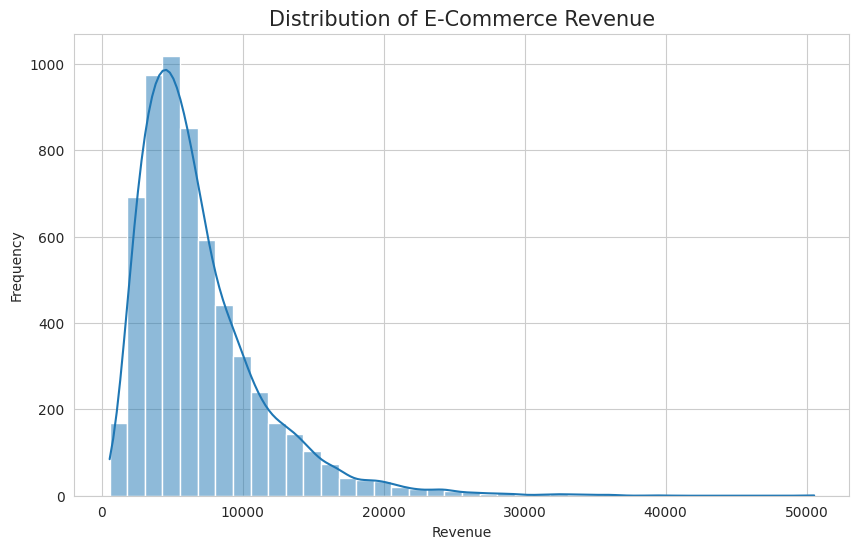

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['Revenue'],
    bins=40,
    kde=True
)

plt.title(
    'Distribution of E-Commerce Revenue',
    fontsize=15
)

plt.xlabel('Revenue')
plt.ylabel('Frequency')

plt.show()

Normality Analysis of Revenue

In [ ]:
sample_revenue = df['Revenue'].dropna()

if len(sample_revenue) > 5000:
    sample_revenue = sample_revenue.sample(
        5000,
        random_state=42
    )

shapiro_stat, shapiro_p = stats.shapiro(
    sample_revenue
)

print("Shapiro-Wilk Statistic:", shapiro_stat)
print("P-value:", shapiro_p)

Shapiro-Wilk Statistic: 0.8409345248326228
P-value: 2.430121715975314e-57


In [ ]:
# Interpretation
alpha = 0.05

if shapiro_p < alpha:
    print(
        "The test suggests that Revenue is not normally distributed."
    )
else:
    print(
        "The test does not provide sufficient evidence against normality."
    )

The test suggests that Revenue is not normally distributed.


Correlation Analysis

In [ ]:
target_derived_columns = [
    'Revenue_Per_Order',
    'Revenue_Per_Marketing_Dollar',
    'Revenue_Per_Visit',
    'Revenue_Per_Unique_Visitor',
    'Revenue_Gap',
    'Revenue_Category'
]

correlation_df = df.drop(
    columns=target_derived_columns,
    errors='ignore'
)

In [ ]:
numeric_for_correlation = (
    correlation_df
    .select_dtypes(
        include=np.number
    )
)

Correlation With Revenue

In [ ]:
revenue_correlations = (
    numeric_for_correlation
    .corr()['Revenue']
    .drop('Revenue')
    .sort_values(
        ascending=False
    )
)

print(revenue_correlations)

Potential_Order_Value            0.9227
Average_Order_Value              0.9062
Discount_Adjusted_Order_Value    0.8932
Seasonality_Index                0.2473
Orders                           0.1514
Visitor_Order_Rate               0.1433
Orders_Per_Ad_Click              0.1122
Product_Availability             0.1011
Estimated_Returning_Orders       0.0700
Conversion_Rate                  0.0442
Estimated_New_Customer_Orders    0.0367
Returning_Customer_Rate          0.0285
Day_of_Week_Num                  0.0200
Is_Weekend                       0.0180
Marketing_Cost_Per_Visitor       0.0142
Marketing_Spend                  0.0133
Email_Campaigns                  0.0124
Ad_Click_Rate                    0.0118
Ad_Clicks                        0.0116
Economic_Index                   0.0097
Day                              0.0057
Quarter                          0.0018
Month                            0.0008
Year                            -0.0000
Week_of_Year                    -0.0005


Absolute Correlation Ranking

In [ ]:
absolute_correlations = (
    revenue_correlations
    .abs()
    .sort_values(
        ascending=False
    )
)

print(
    absolute_correlations
)

Potential_Order_Value           0.9227
Average_Order_Value             0.9062
Discount_Adjusted_Order_Value   0.8932
Seasonality_Index               0.2473
Orders                          0.1514
Visitor_Order_Rate              0.1433
Orders_Per_Ad_Click             0.1122
Availability_Risk               0.1011
Product_Availability            0.1011
Estimated_Returning_Orders      0.0700
Conversion_Rate                 0.0442
Estimated_New_Customer_Orders   0.0367
Returning_Customer_Rate         0.0285
Return_Rate                     0.0262
Unique_Visitors                 0.0251
Shipping_Delay_Days             0.0236
Day_of_Week_Num                 0.0200
Is_Month_Start                  0.0198
Unique_Visitor_Ratio            0.0181
Is_Weekend                      0.0180
Competitor_Price_Index          0.0146
Marketing_Cost_Per_Visitor      0.0142
Marketing_Spend                 0.0133
Email_Campaigns                 0.0124
Ad_Click_Rate                   0.0118
Ad_Clicks                

Correlation Heatmap — Visualization

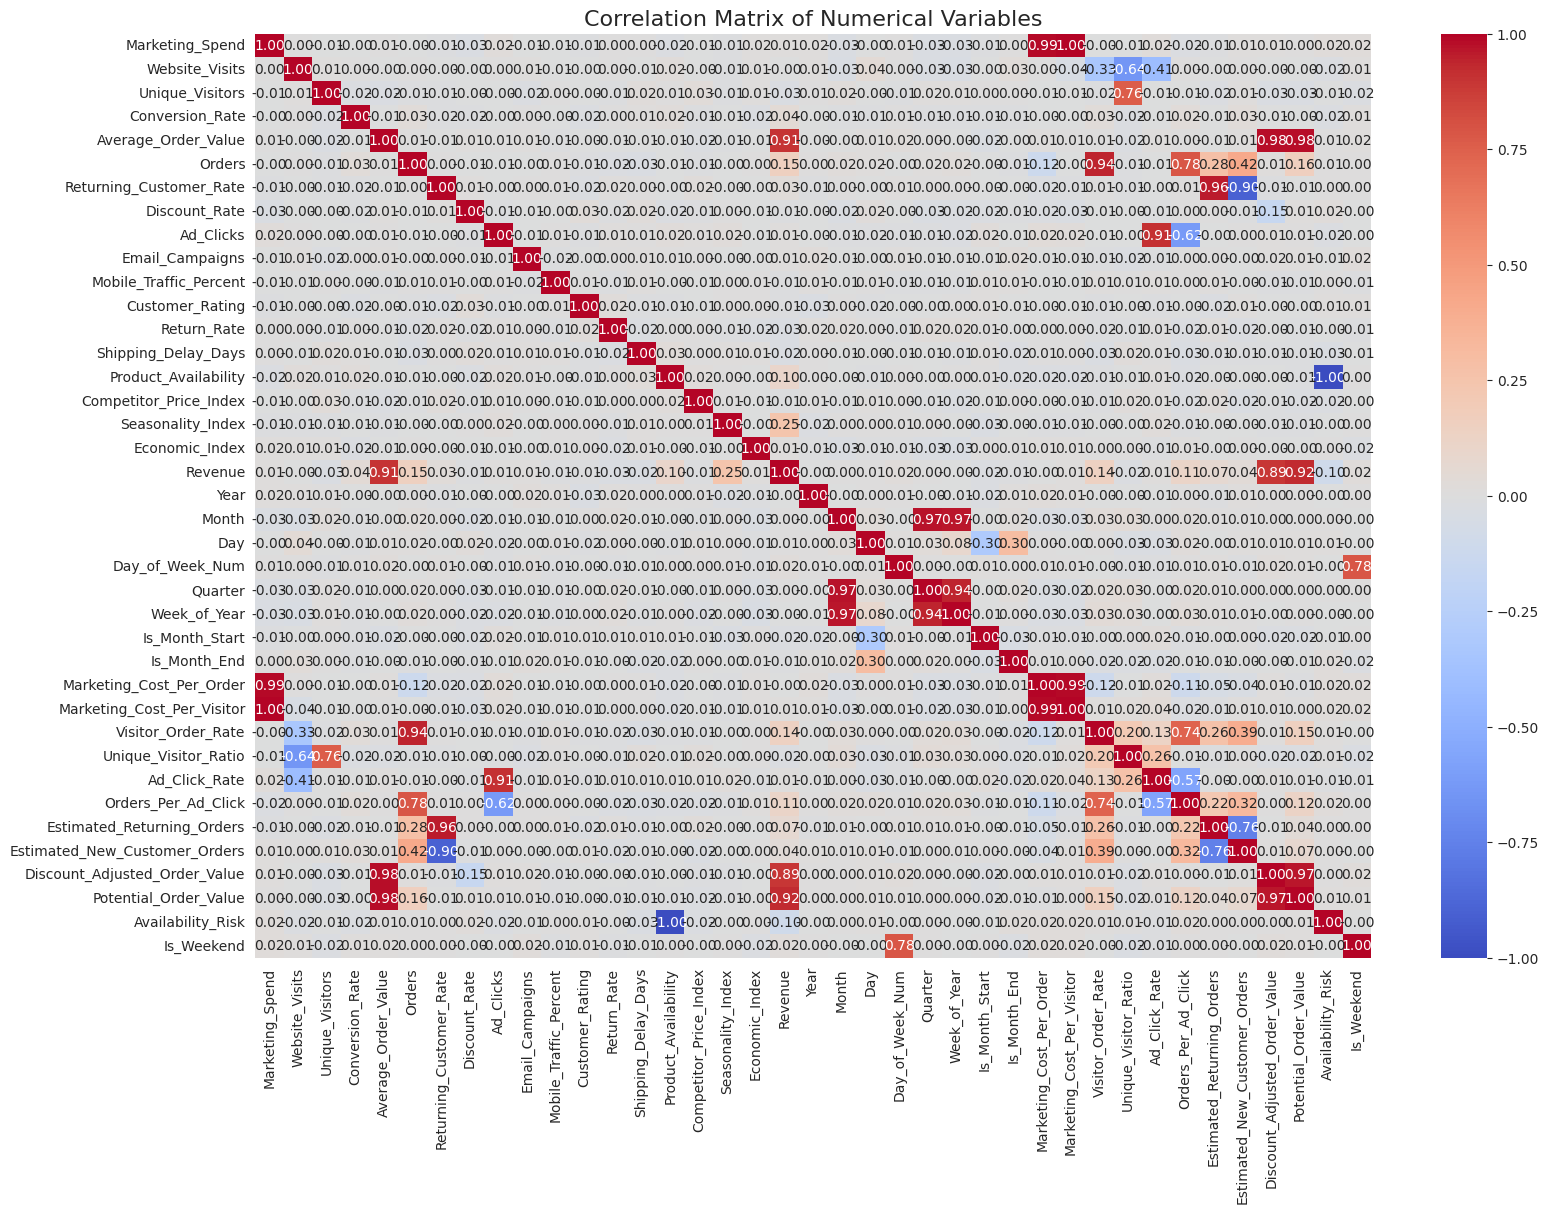

In [ ]:
plt.figure(figsize=(18, 12))

correlation_matrix = (
    numeric_for_correlation
    .corr()
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Correlation Matrix of Numerical Variables',
    fontsize=16
)

plt.show()

Pearson Correlation Tests

In [ ]:
variables_to_test = [
    'Marketing_Spend',
    'Website_Visits',
    'Unique_Visitors',
    'Conversion_Rate',
    'Average_Order_Value',
    'Orders',
    'Returning_Customer_Rate',
    'Discount_Rate',
    'Ad_Clicks',
    'Customer_Rating',
    'Return_Rate',
    'Shipping_Delay_Days',
    'Product_Availability',
    'Competitor_Price_Index',
    'Seasonality_Index',
    'Economic_Index'
]

In [ ]:
pearson_results = []

for variable in variables_to_test:

    if variable in df.columns:

        temp = df[
            [
                variable,
                'Revenue'
            ]
        ].dropna()

        r, p = pearsonr(
            temp[variable],
            temp['Revenue']
        )

        pearson_results.append({
            'Variable': variable,
            'Pearson_Correlation': r,
            'P_Value': p
        })

pearson_results_df = pd.DataFrame(
    pearson_results
)

pearson_results_df = (
    pearson_results_df
    .sort_values(
        'Pearson_Correlation',
        ascending=False
    )
)

print(pearson_results_df)

                   Variable  Pearson_Correlation  P_Value
4       Average_Order_Value               0.9062   0.0000
14        Seasonality_Index               0.2473   0.0000
5                    Orders               0.1514   0.0000
12     Product_Availability               0.1011   0.0000
3           Conversion_Rate               0.0442   0.0006
6   Returning_Customer_Rate               0.0285   0.0273
0           Marketing_Spend               0.0133   0.3024
8                 Ad_Clicks               0.0116   0.3674
15           Economic_Index               0.0097   0.4546
1            Website_Visits              -0.0030   0.8179
7             Discount_Rate              -0.0078   0.5441
9           Customer_Rating              -0.0081   0.5287
13   Competitor_Price_Index              -0.0146   0.2587
11      Shipping_Delay_Days              -0.0236   0.0680
2           Unique_Visitors              -0.0251   0.0514
10              Return_Rate              -0.0262   0.0428


Statistical Significance of Correlations

In [ ]:
pearson_results_df['Significant_at_5%'] = (
    pearson_results_df['P_Value'] < 0.05
)

print(pearson_results_df)

                   Variable  Pearson_Correlation  P_Value  Significant_at_5%
4       Average_Order_Value               0.9062   0.0000               True
14        Seasonality_Index               0.2473   0.0000               True
5                    Orders               0.1514   0.0000               True
12     Product_Availability               0.1011   0.0000               True
3           Conversion_Rate               0.0442   0.0006               True
6   Returning_Customer_Rate               0.0285   0.0273               True
0           Marketing_Spend               0.0133   0.3024              False
8                 Ad_Clicks               0.0116   0.3674              False
15           Economic_Index               0.0097   0.4546              False
1            Website_Visits              -0.0030   0.8179              False
7             Discount_Rate              -0.0078   0.5441              False
9           Customer_Rating              -0.0081   0.5287              False

In [ ]:
pearson_results_df['Significant_at_1%'] = (
    pearson_results_df['P_Value'] < 0.01
)

print(pearson_results_df)

                   Variable  Pearson_Correlation  P_Value  Significant_at_5%  \
4       Average_Order_Value               0.9062   0.0000               True   
14        Seasonality_Index               0.2473   0.0000               True   
5                    Orders               0.1514   0.0000               True   
12     Product_Availability               0.1011   0.0000               True   
3           Conversion_Rate               0.0442   0.0006               True   
6   Returning_Customer_Rate               0.0285   0.0273               True   
0           Marketing_Spend               0.0133   0.3024              False   
8                 Ad_Clicks               0.0116   0.3674              False   
15           Economic_Index               0.0097   0.4546              False   
1            Website_Visits              -0.0030   0.8179              False   
7             Discount_Rate              -0.0078   0.5441              False   
9           Customer_Rating             

Spearman Correlation

In [ ]:
spearman_results = []

for variable in variables_to_test:

    if variable in df.columns:

        temp = df[
            [
                variable,
                'Revenue'
            ]
        ].dropna()

        rho, p = spearmanr(
            temp[variable],
            temp['Revenue']
        )

        spearman_results.append({
            'Variable': variable,
            'Spearman_Correlation': rho,
            'P_Value': p
        })

spearman_results_df = pd.DataFrame(
    spearman_results
)

spearman_results_df = (
    spearman_results_df
    .sort_values(
        'Spearman_Correlation',
        ascending=False
    )
)

print(spearman_results_df)

                   Variable  Spearman_Correlation  P_Value
4       Average_Order_Value                0.9113   0.0000
14        Seasonality_Index                0.2562   0.0000
5                    Orders                0.1405   0.0000
12     Product_Availability                0.1122   0.0000
3           Conversion_Rate                0.0459   0.0004
0           Marketing_Spend                0.0237   0.0661
6   Returning_Customer_Rate                0.0173   0.1795
15           Economic_Index                0.0117   0.3664
8                 Ad_Clicks                0.0084   0.5132
7             Discount_Rate               -0.0032   0.8023
1            Website_Visits               -0.0109   0.4001
9           Customer_Rating               -0.0113   0.3836
11      Shipping_Delay_Days               -0.0167   0.1963
2           Unique_Visitors               -0.0175   0.1751
13   Competitor_Price_Index               -0.0181   0.1608
10              Return_Rate               -0.0190   0.14

Compare Pearson and Spearman Results

In [ ]:
correlation_comparison = pearson_results_df[
    [
        'Variable',
        'Pearson_Correlation',
        'P_Value'
    ]
].merge(
    spearman_results_df[
        [
            'Variable',
            'Spearman_Correlation'
        ]
    ],
    on='Variable'
)

print(correlation_comparison)

                   Variable  Pearson_Correlation  P_Value  \
0       Average_Order_Value               0.9062   0.0000   
1         Seasonality_Index               0.2473   0.0000   
2                    Orders               0.1514   0.0000   
3      Product_Availability               0.1011   0.0000   
4           Conversion_Rate               0.0442   0.0006   
5   Returning_Customer_Rate               0.0285   0.0273   
6           Marketing_Spend               0.0133   0.3024   
7                 Ad_Clicks               0.0116   0.3674   
8            Economic_Index               0.0097   0.4546   
9            Website_Visits              -0.0030   0.8179   
10            Discount_Rate              -0.0078   0.5441   
11          Customer_Rating              -0.0081   0.5287   
12   Competitor_Price_Index              -0.0146   0.2587   
13      Shipping_Delay_Days              -0.0236   0.0680   
14          Unique_Visitors              -0.0251   0.0514   
15              Return_R

Marketing Spend vs Revenue — Visualization

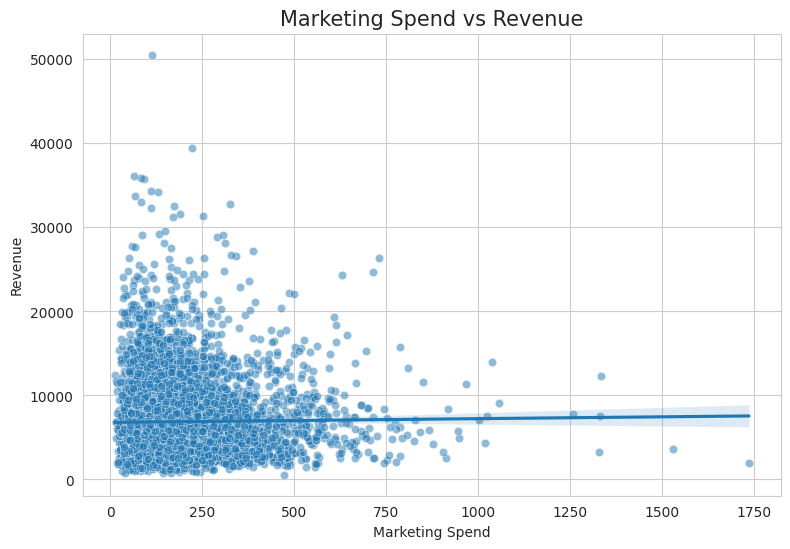

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Marketing_Spend',
    y='Revenue',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='Marketing_Spend',
    y='Revenue',
    scatter=False
)

plt.title(
    'Marketing Spend vs Revenue',
    fontsize=15
)

plt.xlabel('Marketing Spend')
plt.ylabel('Revenue')

plt.show()

Orders vs Revenue — Visualization

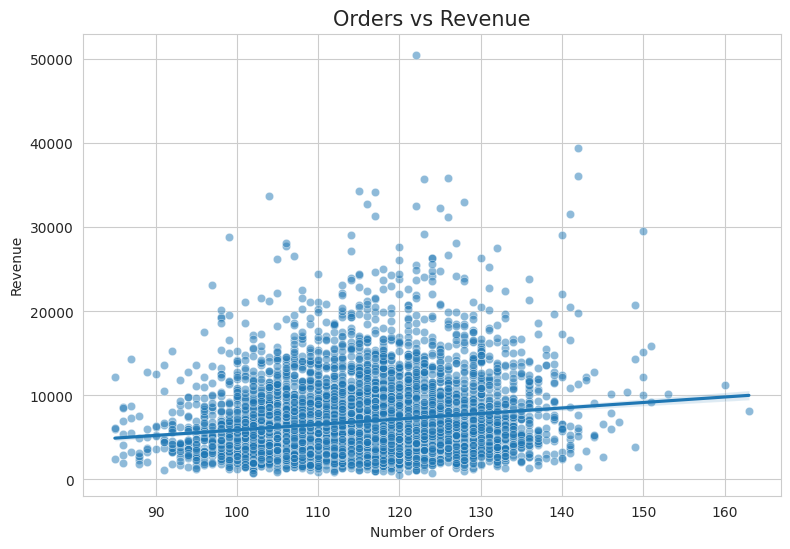

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Orders',
    y='Revenue',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='Orders',
    y='Revenue',
    scatter=False
)

plt.title(
    'Orders vs Revenue',
    fontsize=15
)

plt.xlabel('Number of Orders')
plt.ylabel('Revenue')

plt.show()

Statistical Test: Weekday vs Weekend Revenue

In [ ]:
print(
    df['Is_Weekend']
    .value_counts()
)

Is_Weekend
0    4350
1    1650
Name: count, dtype: int64


In [ ]:
weekday_revenue = df[
    df['Is_Weekend'] == 0
]['Revenue'].dropna()

weekend_revenue = df[
    df['Is_Weekend'] == 1
]['Revenue'].dropna()

In [ ]:
weekday_summary = {
    'Count': len(weekday_revenue),
    'Mean': weekday_revenue.mean(),
    'Median': weekday_revenue.median(),
    'Std': weekday_revenue.std()
}

weekend_summary = {
    'Count': len(weekend_revenue),
    'Mean': weekend_revenue.mean(),
    'Median': weekend_revenue.median(),
    'Std': weekend_revenue.std()
}

print("Weekday:")
print(weekday_summary)

print("\nWeekend:")
print(weekend_summary)

Weekday:
{'Count': 4350, 'Mean': np.float64(6830.429526436781), 'Median': 5671.745000000001, 'Std': 4446.483169151453}

Weekend:
{'Count': 1650, 'Mean': np.float64(7009.374515151516), 'Median': 6024.48, 'Std': 4430.120258116553}


Weekday vs Weekend Revenue — Visualization

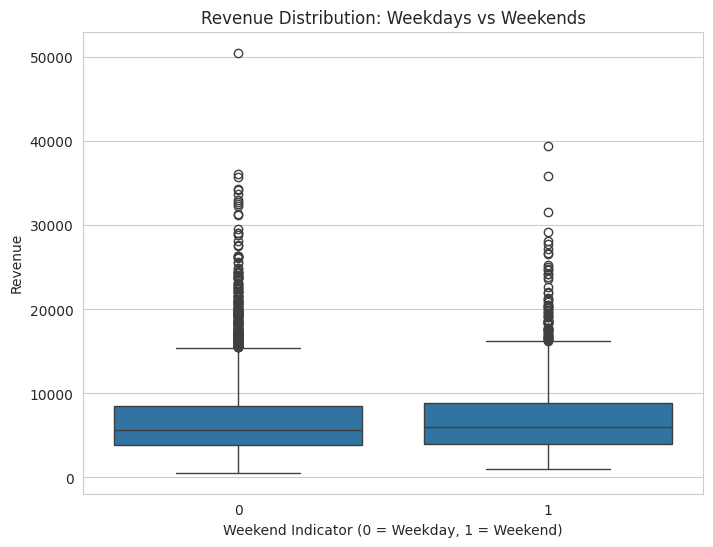

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='Is_Weekend',
    y='Revenue'
)

plt.title(
    'Revenue Distribution: Weekdays vs Weekends'
)

plt.xlabel(
    'Weekend Indicator (0 = Weekday, 1 = Weekend)'
)

plt.ylabel('Revenue')

plt.show()

Revenue Analysis by Sales Channel

In [ ]:
sales_channel_stats = (
    df
    .groupby('Sales_Channel')
    ['Revenue']
    .agg([
        'count',
        'mean',
        'median',
        'std',
        'min',
        'max'
    ])
    .sort_values(
        'mean',
        ascending=False
    )
)

print(sales_channel_stats)

               count      mean    median       std      min        max
Sales_Channel                                                         
Mobile App      2259 7250.5002 6120.5800 4654.0340 964.1200 50542.5300
Website         2705 6833.1375 5762.8500 4322.7609 751.9800 36107.1900
Marketplace     1036 6192.3933 5101.2150 4187.0126 566.1600 31398.3800


Revenue by Sales Channel — Visualization

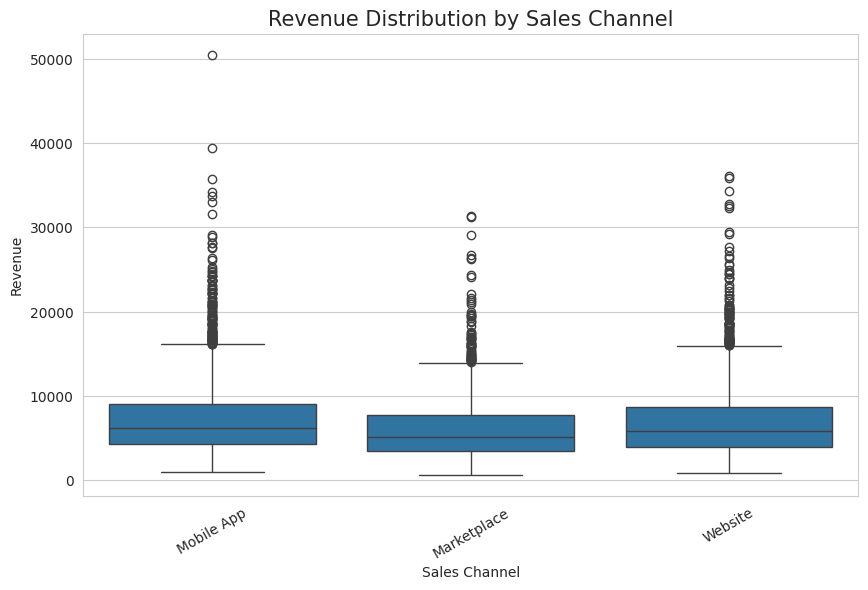

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Sales_Channel',
    y='Revenue'
)

plt.title(
    'Revenue Distribution by Sales Channel',
    fontsize=15
)

plt.xlabel('Sales Channel')
plt.ylabel('Revenue')

plt.xticks(rotation=30)

plt.show()

Revenue Analysis by Region

In [ ]:
region_stats = (
    df
    .groupby('Region')
    ['Revenue']
    .agg([
        'count',
        'mean',
        'median',
        'std',
        'min',
        'max'
    ])
    .sort_values(
        'mean',
        ascending=False
    )
)

print(region_stats)

         count      mean    median       std       min        max
Region                                                           
West      1169 7311.2787 6023.8100 4696.4065  566.1600 34201.3100
North     1114 6964.2646 5807.2250 4786.8169 1055.2900 50542.5300
East      1216 6809.7290 5714.3050 4419.3229  806.0100 39450.7600
Central   1281 6742.6417 5805.5500 4113.4159  895.6100 35795.8800
South     1220 6602.3003 5526.5000 4188.4535  751.9800 34321.2100


Revenue by Region — Visualization

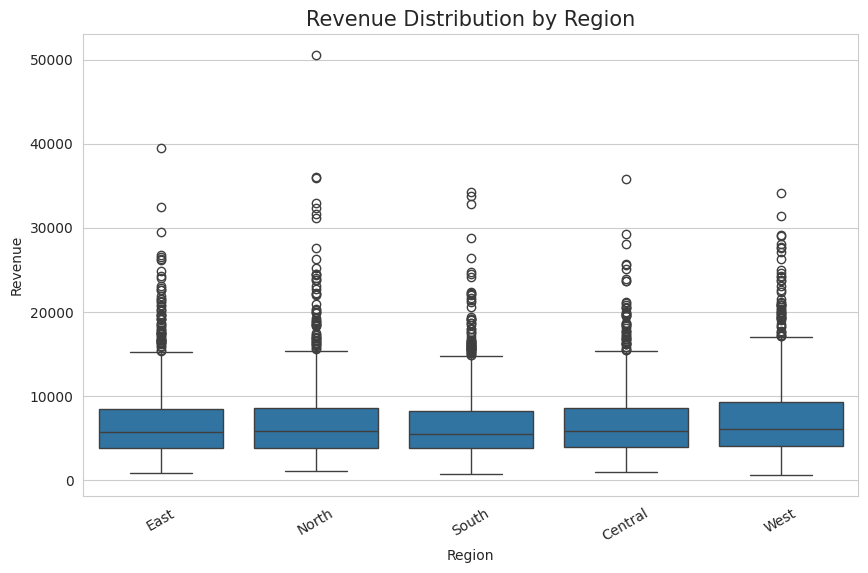

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Region',
    y='Revenue'
)

plt.title(
    'Revenue Distribution by Region',
    fontsize=15
)

plt.xlabel('Region')
plt.ylabel('Revenue')

plt.xticks(rotation=30)

plt.show()

Monthly Revenue Statistical Analysis

In [ ]:
df['Year_Month'] = (
    df['Date']
    .dt.to_period('M')
    .astype(str)
)

monthly_revenue = (
    df
    .groupby('Year_Month')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Average_Revenue=('Revenue', 'mean'),
        Median_Revenue=('Revenue', 'median'),
        Total_Orders=('Orders', 'sum'),
        Average_Orders=('Orders', 'mean'),
        Marketing_Spend=(
            'Marketing_Spend',
            'sum'
        )
    )
)

print(monthly_revenue)

            Total_Revenue  Average_Revenue  Median_Revenue  Total_Orders  \
Year_Month                                                                 
2022-01       832240.0000        6657.9200       5398.9900         14439   
2022-02       760928.5900        6855.2125       5610.1900         12833   
2022-03       808167.7700        6517.4820       5844.9400         14084   
2022-04       823810.0800        6697.6429       5973.6300         14138   
2022-05       873685.0300        6825.6643       5553.2250         14774   
2022-06       998022.9400        7028.3306       5914.6550         16260   
2022-07       939933.7900        7067.1714       6052.8900         15293   
2022-08       733148.3400        6604.9400       5492.4400         12711   
2022-09       763564.7500        6941.4977       5759.1250         12826   
2022-10       959866.5800        7006.3254       5876.8500         15824   
2022-11       818815.8500        7182.5952       5935.7450         13199   
2022-12     

Monthly Revenue Trend — Visualization

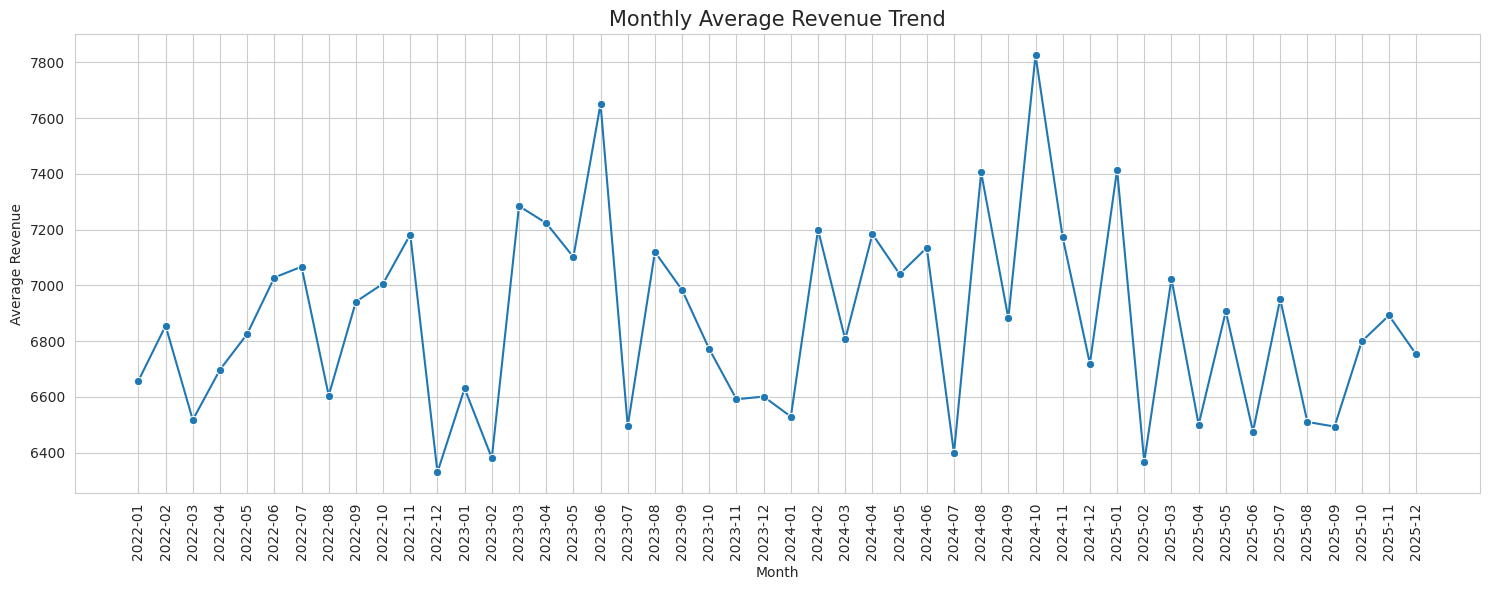

In [ ]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly_revenue,
    x=monthly_revenue.index,
    y='Average_Revenue',
    marker='o'
)

plt.title(
    'Monthly Average Revenue Trend',
    fontsize=15
)

plt.xlabel('Month')
plt.ylabel('Average Revenue')

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

Monthly Revenue Growth

In [ ]:
monthly_revenue['Revenue_Growth_Percent'] = (
    monthly_revenue['Total_Revenue']
    .pct_change()
    * 100
)

print(
    monthly_revenue[
        [
            'Total_Revenue',
            'Revenue_Growth_Percent'
        ]
    ]
)

            Total_Revenue  Revenue_Growth_Percent
Year_Month                                       
2022-01       832240.0000                     NaN
2022-02       760928.5900                 -8.5686
2022-03       808167.7700                  6.2081
2022-04       823810.0800                  1.9355
2022-05       873685.0300                  6.0542
2022-06       998022.9400                 14.2314
2022-07       939933.7900                 -5.8204
2022-08       733148.3400                -22.0000
2022-09       763564.7500                  4.1487
2022-10       959866.5800                 25.7086
2022-11       818815.8500                -14.6948
2022-12       917801.6500                 12.0889
2023-01       722715.5800                -21.2558
2023-02       803946.2100                 11.2396
2023-03       866901.9700                  7.8308
2023-04       939074.4200                  8.3253
2023-05      1015593.6900                  8.1484
2023-06       987014.5600                 -2.8140


Identify Highest and Lowest Revenue Months

In [ ]:
highest_month = (
    monthly_revenue[
        'Total_Revenue'
    ].idxmax()
)

lowest_month = (
    monthly_revenue[
        'Total_Revenue'
    ].idxmin()
)

print(
    "Month with highest total revenue:",
    highest_month
)

print(
    "Month with lowest total revenue:",
    lowest_month
)

Month with highest total revenue: 2024-08
Month with lowest total revenue: 2023-01


Chi-Square Test: Sales Channel vs Revenue Category

In [ ]:
print(
    pd.crosstab(
        df['Sales_Channel'],
        df['Revenue_Category']
    )
)

Revenue_Category  High Revenue  Low Revenue  Medium Revenue  Very High Revenue
Sales_Channel                                                                 
Marketplace                227          337             274                198
Mobile App                 612          472             563                612
Website                    661          691             663                690


In [ ]:
contingency_table = pd.crosstab(
    df['Sales_Channel'],
    df['Revenue_Category']
)

chi2, p_value, dof, expected = (
    chi2_contingency(
        contingency_table
    )
)

print(
    "Chi-square statistic:",
    chi2
)

print(
    "Degrees of freedom:",
    dof
)

print(
    "P-value:",
    p_value
)

Chi-square statistic: 67.02865423682856
Degrees of freedom: 6
P-value: 1.6605268978058495e-12


In [ ]:
if p_value < 0.05:
    print(
        "There is a statistically significant association "
        "between Sales Channel and Revenue Category."
    )
else:
    print(
        "There is not sufficient statistical evidence "
        "of an association between Sales Channel and Revenue Category."
    )

There is a statistically significant association between Sales Channel and Revenue Category.


Business Efficiency Analysis

In [ ]:
efficiency_summary = df[
    [
        'Revenue_Per_Order',
        'Revenue_Per_Marketing_Dollar',
        'Marketing_Cost_Per_Order',
        'Marketing_Cost_Per_Visitor',
        'Revenue_Per_Visit'
    ]
].describe().T

print(efficiency_summary)

                                 count    mean     std    min     25%     50%  \
Revenue_Per_Order            6000.0000 59.7541 37.7907 4.7180 34.1282 50.2455   
Revenue_Per_Marketing_Dollar 6000.0000 57.4522 64.5527 1.1437 21.1110 37.9546   
Marketing_Cost_Per_Order     6000.0000  1.6219  1.1970 0.1109  0.8335  1.3146   
Marketing_Cost_Per_Visitor   6000.0000  0.2057  0.1500 0.0129  0.1062  0.1662   
Revenue_Per_Visit            6000.0000  7.6468  4.9367 0.5891  4.3170  6.3888   

                                 75%       max  
Revenue_Per_Order            75.1703  414.2830  
Revenue_Per_Marketing_Dollar 68.8631 1002.9581  
Marketing_Cost_Per_Order      2.0299   14.1624  
Marketing_Cost_Per_Visitor    0.2574    1.8800  
Revenue_Per_Visit             9.5281   53.6545  


Average Business Efficiency by Sales Channel

In [ ]:
channel_efficiency = (
    df
    .groupby('Sales_Channel')
    .agg(
        Average_Revenue=(
            'Revenue',
            'mean'
        ),

        Average_Revenue_Per_Order=(
            'Revenue_Per_Order',
            'mean'
        ),

        Average_Revenue_Per_Marketing_Dollar=(
            'Revenue_Per_Marketing_Dollar',
            'mean'
        ),

        Average_Marketing_Cost_Per_Order=(
            'Marketing_Cost_Per_Order',
            'mean'
        ),

        Average_Revenue_Per_Visit=(
            'Revenue_Per_Visit',
            'mean'
        )
    )
)

print(channel_efficiency)

               Average_Revenue  Average_Revenue_Per_Order  \
Sales_Channel                                               
Marketplace          6192.3933                    53.3789   
Mobile App           7250.5002                    62.9887   
Website              6833.1375                    59.4944   

               Average_Revenue_Per_Marketing_Dollar  \
Sales_Channel                                         
Marketplace                                 50.2486   
Mobile App                                  61.2546   
Website                                     57.0356   

               Average_Marketing_Cost_Per_Order  Average_Revenue_Per_Visit  
Sales_Channel                                                               
Marketplace                              1.6167                     6.8851  
Mobile App                               1.5987                     8.0578  
Website                                  1.6432                     7.5954  


Relationship Between Customer Rating and Revenue

In [ ]:
rating_corr, rating_p = pearsonr(
    df['Customer_Rating'],
    df['Revenue']
)

print(
    "Customer Rating vs Revenue"
)

print(
    "Correlation:",
    rating_corr
)

print(
    "P-value:",
    rating_p
)

Customer Rating vs Revenue
Correlation: -0.008133878519666285
P-value: 0.5287425641124529


Multiple Linear Regression for Statistical Analysis

In [ ]:
regression_features = [
    'Marketing_Spend',
    'Website_Visits',
    'Conversion_Rate',
    'Average_Order_Value',
    'Orders',
    'Returning_Customer_Rate',
    'Discount_Rate',
    'Ad_Clicks',
    'Customer_Rating',
    'Return_Rate',
    'Shipping_Delay_Days',
    'Product_Availability',
    'Competitor_Price_Index',
    'Seasonality_Index',
    'Economic_Index'
]

In [ ]:
regression_data = df[
    regression_features +
    ['Revenue']
].dropna()

print(
    "Regression dataset shape:",
    regression_data.shape
)

Regression dataset shape: (6000, 16)


In [ ]:
X = regression_data[
    regression_features
]

y = regression_data[
    'Revenue'
]

X = sm.add_constant(X)

ols_model = sm.OLS(
    y,
    X
).fit()

print(
    ols_model.summary()
)

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     4972.
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        21:26:02   Log-Likelihood:                -51107.
No. Observations:                6000   AIC:                         1.022e+05
Df Residuals:                    5984   BIC:                         1.024e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                   -2

Extract Regression Coefficients

In [ ]:
regression_results = pd.DataFrame({
    'Coefficient':
        ols_model.params,

    'P_Value':
        ols_model.pvalues,

    'Std_Error':
        ols_model.bse,

    'Lower_95_CI':
        ols_model.conf_int()[0],

    'Upper_95_CI':
        ols_model.conf_int()[1]
})

print(regression_results)

                         Coefficient  P_Value  Std_Error  Lower_95_CI  \
const                    -22913.7742   0.0000   714.3787  -24314.2141   
Marketing_Spend               0.4045   0.0005     0.1161       0.1770   
Website_Visits               -0.2474   0.6482     0.5422      -1.3104   
Conversion_Rate             193.8271   0.0000    14.5128     165.3767   
Average_Order_Value         149.0690   0.0000     0.5776     147.9367   
Orders                       62.0219   0.0000     1.5213      59.0396   
Returning_Customer_Rate      13.6864   0.0000     1.3148      11.1089   
Discount_Rate                -7.7854   0.0000     1.8992     -11.5084   
Ad_Clicks                    -0.2247   0.8466     1.1612      -2.5010   
Customer_Rating             -20.0839   0.5010    29.8467     -78.5942   
Return_Rate                 -20.1783   0.0000     4.4978     -28.9957   
Shipping_Delay_Days         -70.9114   0.0000    12.6278     -95.6664   
Product_Availability         75.1391   0.0000     2

Statistically Significant Regression Features

In [ ]:
significant_regression_features = (
    regression_results[
        regression_results['P_Value'] < 0.05
    ]
)

print(
    significant_regression_features
)

                         Coefficient  P_Value  Std_Error  Lower_95_CI  \
const                    -22913.7742   0.0000   714.3787  -24314.2141   
Marketing_Spend               0.4045   0.0005     0.1161       0.1770   
Conversion_Rate             193.8271   0.0000    14.5128     165.3767   
Average_Order_Value         149.0690   0.0000     0.5776     147.9367   
Orders                       62.0219   0.0000     1.5213      59.0396   
Returning_Customer_Rate      13.6864   0.0000     1.3148      11.1089   
Discount_Rate                -7.7854   0.0000     1.8992     -11.5084   
Return_Rate                 -20.1783   0.0000     4.4978     -28.9957   
Shipping_Delay_Days         -70.9114   0.0000    12.6278     -95.6664   
Product_Availability         75.1391   0.0000     2.4646      70.3076   
Seasonality_Index          6638.8107   0.0000    90.0947    6462.1926   
Economic_Index               13.5779   0.0000     3.1395       7.4233   

                         Upper_95_CI  
const      

Regression Model R-Squared

In [ ]:
print(
    "R-squared:",
    ols_model.rsquared
)

print(
    "Adjusted R-squared:",
    ols_model.rsquared_adj
)

R-squared: 0.9257303482312951
Adjusted R-squared: 0.9255441776469818


Regression Model F-Test

In [ ]:
print(
    "F-statistic:",
    ols_model.fvalue
)

print(
    "F-test p-value:",
    ols_model.f_pvalue
)

F-statistic: 4972.484518142743
F-test p-value: 0.0


In [ ]:
if ols_model.f_pvalue < 0.05:
    print(
        "The overall regression model is statistically significant."
    )
else:
    print(
        "The overall regression model is not statistically significant at the 5% level."
    )

The overall regression model is statistically significant.


Final Statistical Summary

In [ ]:
print("=" * 80)
print("TASK 3 - STATISTICAL ANALYSIS SUMMARY")
print("=" * 80)

print("\nDataset:")
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nRevenue:")
print("Mean:", df['Revenue'].mean())
print("Median:", df['Revenue'].median())
print("Std Dev:", df['Revenue'].std())
print("Skewness:", df['Revenue'].skew())
print("Kurtosis:", df['Revenue'].kurtosis())


print("\nTop Correlations With Revenue:")

print(
    revenue_correlations
    .abs()
    .sort_values(
        ascending=False
    )
    .head(10)
)

print("\nWeekday vs Weekend Test:")
print(
    "Mann-Whitney p-value:",
    p_value
)


print("\nRegression:")
print(
    "R-squared:",
    ols_model.rsquared
)

print(
    "Adjusted R-squared:",
    ols_model.rsquared_adj
)

print(
    "Overall regression p-value:",
    ols_model.f_pvalue
)

print("=" * 80)

TASK 3 - STATISTICAL ANALYSIS SUMMARY

Dataset:
Rows: 6000
Columns: 56

Revenue:
Mean: 6879.639398333334
Median: 5763.245
Std Dev: 4442.339107229835
Skewness: 2.0214740176026242
Kurtosis: 7.004076209596788

Top Correlations With Revenue:
Potential_Order_Value           0.9227
Average_Order_Value             0.9062
Discount_Adjusted_Order_Value   0.8932
Seasonality_Index               0.2473
Orders                          0.1514
Visitor_Order_Rate              0.1433
Orders_Per_Ad_Click             0.1122
Availability_Risk               0.1011
Product_Availability            0.1011
Estimated_Returning_Orders      0.0700
Name: Revenue, dtype: float64

Weekday vs Weekend Test:
Mann-Whitney p-value: 1.6605268978058495e-12

Regression:
R-squared: 0.9257303482312951
Adjusted R-squared: 0.9255441776469818
Overall regression p-value: 0.0


Conversion Rate vs Revenue

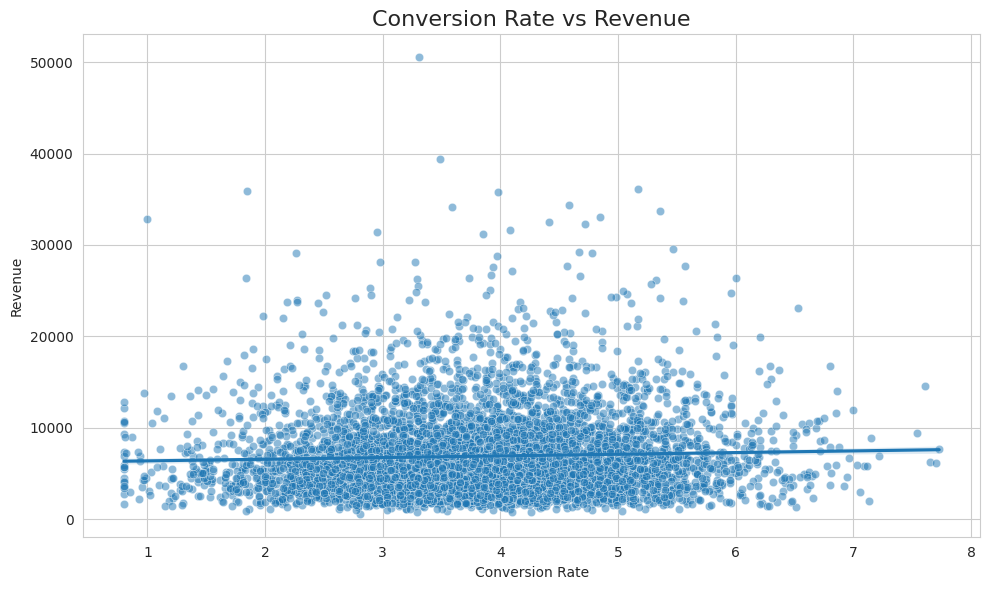

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Conversion_Rate',
    y='Revenue',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='Conversion_Rate',
    y='Revenue',
    scatter=False
)

plt.title(
    'Conversion Rate vs Revenue',
    fontsize=16
)

plt.xlabel('Conversion Rate')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

Returning Customer Rate vs Revenue

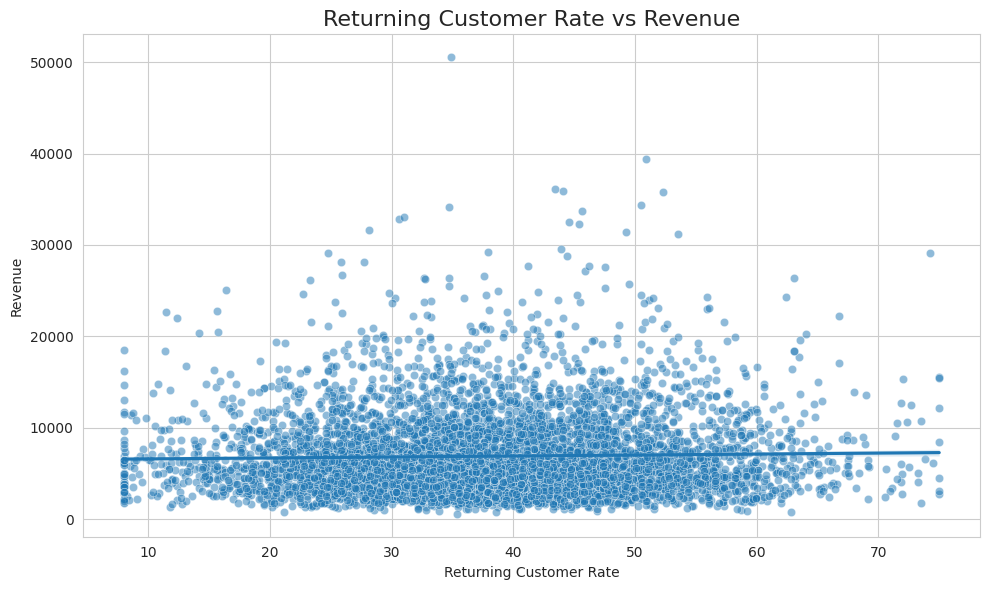

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Returning_Customer_Rate',
    y='Revenue',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='Returning_Customer_Rate',
    y='Revenue',
    scatter=False
)

plt.title(
    'Returning Customer Rate vs Revenue',
    fontsize=16
)

plt.xlabel('Returning Customer Rate')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

Discount Rate vs Revenue

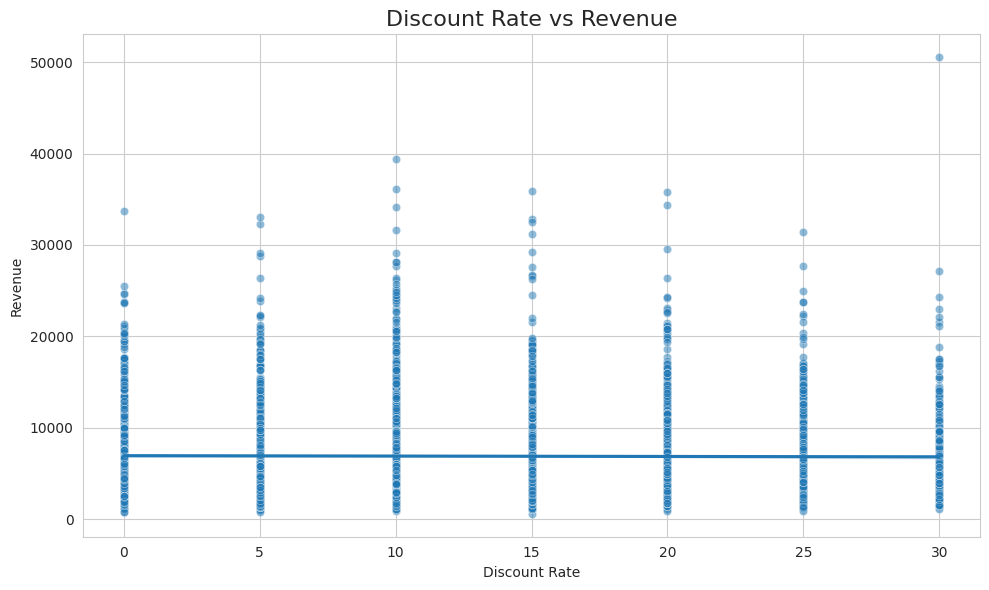

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Discount_Rate',
    y='Revenue',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='Discount_Rate',
    y='Revenue',
    scatter=False
)

plt.title(
    'Discount Rate vs Revenue',
    fontsize=16
)

plt.xlabel('Discount Rate')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

Ad Clicks vs Revenue

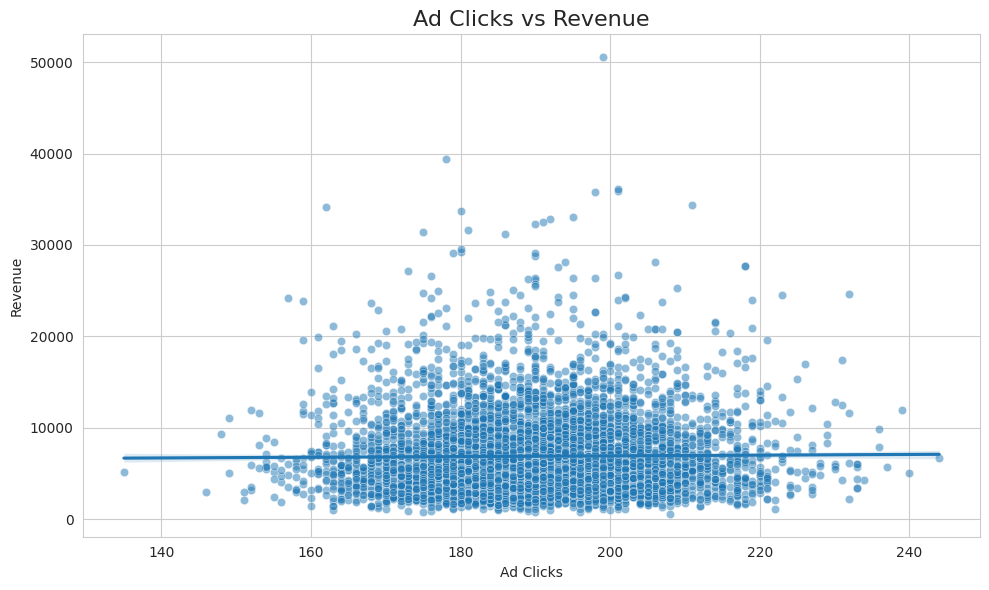

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Ad_Clicks',
    y='Revenue',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='Ad_Clicks',
    y='Revenue',
    scatter=False
)

plt.title(
    'Ad Clicks vs Revenue',
    fontsize=16
)

plt.xlabel('Ad Clicks')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

Website Visits vs Revenue

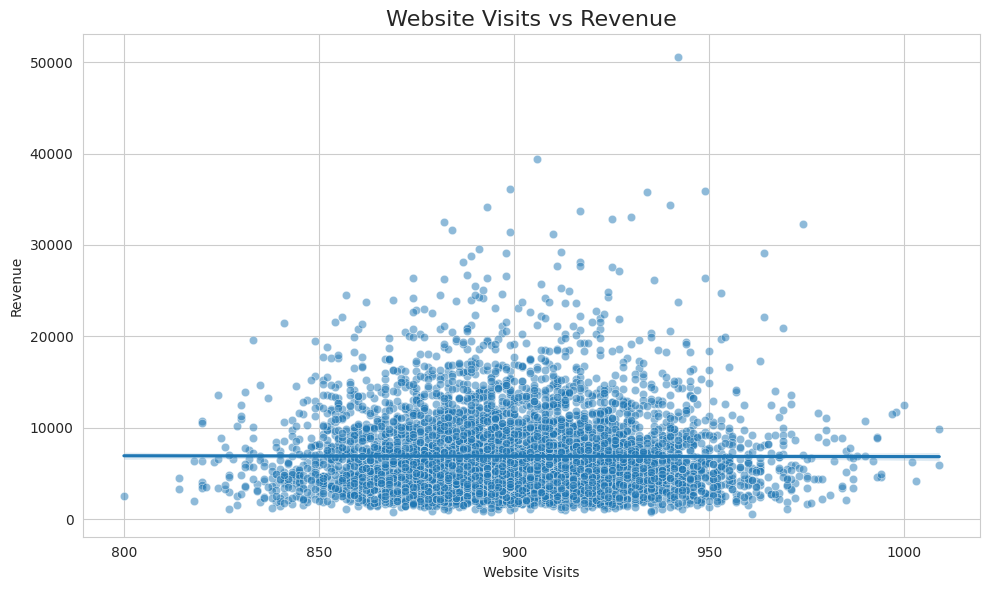

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Website_Visits',
    y='Revenue',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='Website_Visits',
    y='Revenue',
    scatter=False
)

plt.title(
    'Website Visits vs Revenue',
    fontsize=16
)

plt.xlabel('Website Visits')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

Revenue by Day of the Week

In [ ]:
df['Day_Name'] = df['Date'].dt.day_name()

In [ ]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

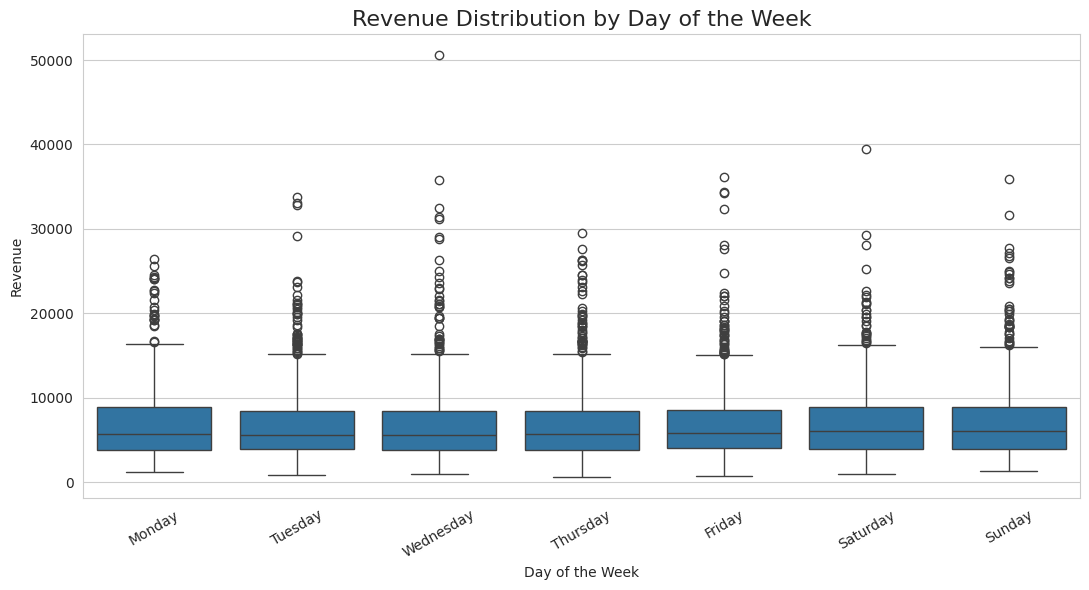

In [ ]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x='Day_Name',
    y='Revenue',
    order=day_order
)

plt.title(
    'Revenue Distribution by Day of the Week',
    fontsize=16
)

plt.xlabel('Day of the Week')
plt.ylabel('Revenue')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Average Revenue by Day of the Week

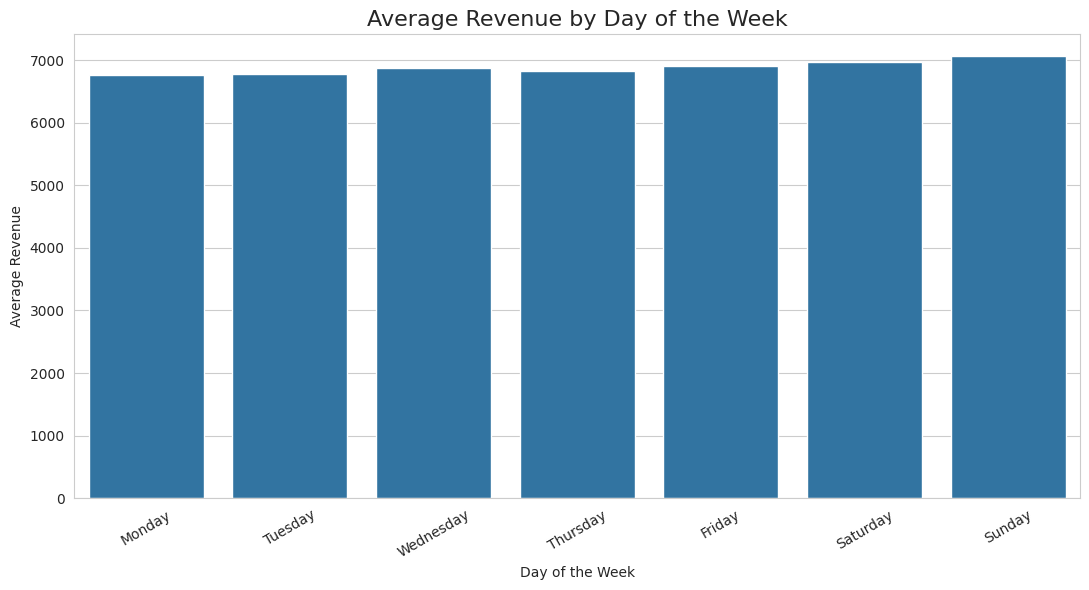

In [ ]:
day_revenue = (
    df.groupby('Day_Name')['Revenue']
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=day_revenue.index,
    y=day_revenue.values
)

plt.title(
    'Average Revenue by Day of the Week',
    fontsize=16
)

plt.xlabel('Day of the Week')
plt.ylabel('Average Revenue')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Shipping Delay vs Revenue

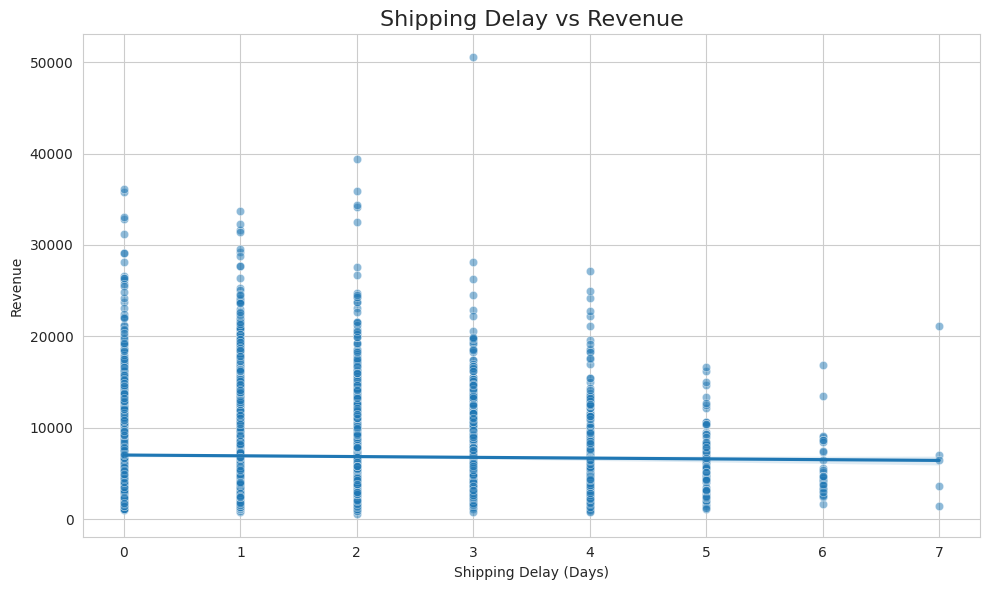

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Shipping_Delay_Days',
    y='Revenue',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='Shipping_Delay_Days',
    y='Revenue',
    scatter=False
)

plt.title(
    'Shipping Delay vs Revenue',
    fontsize=16
)

plt.xlabel('Shipping Delay (Days)')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

Product Availability vs Revenue

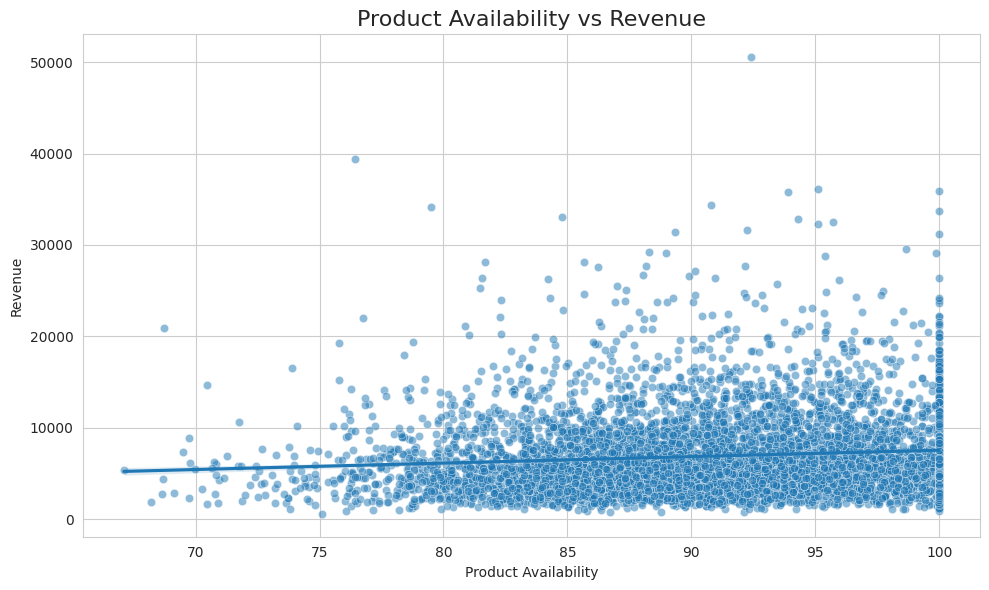

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Product_Availability',
    y='Revenue',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='Product_Availability',
    y='Revenue',
    scatter=False
)

plt.title(
    'Product Availability vs Revenue',
    fontsize=16
)

plt.xlabel('Product Availability')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

Competitor Price Index vs Revenue

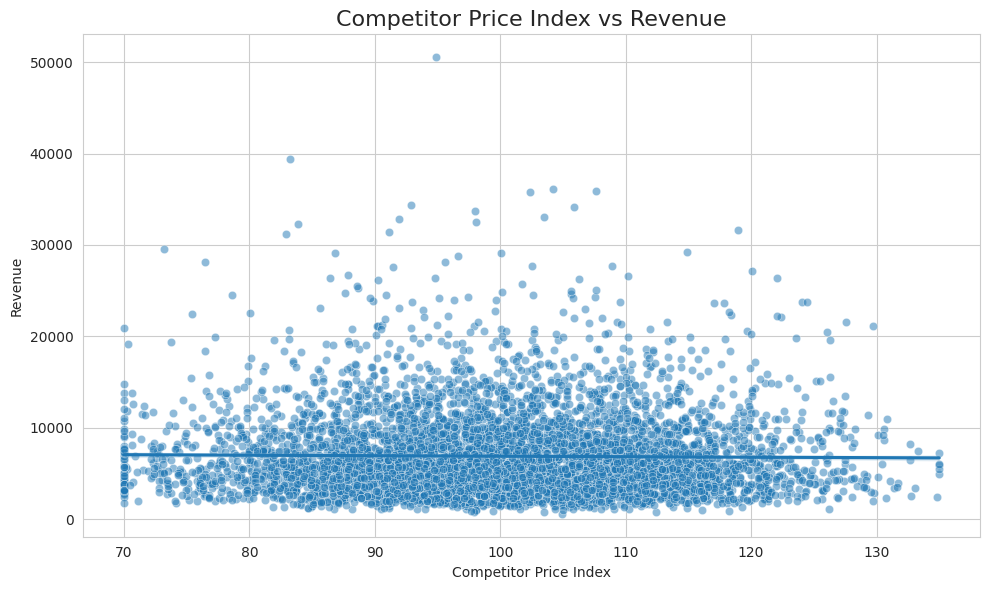

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Competitor_Price_Index',
    y='Revenue',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='Competitor_Price_Index',
    y='Revenue',
    scatter=False
)

plt.title(
    'Competitor Price Index vs Revenue',
    fontsize=16
)

plt.xlabel('Competitor Price Index')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

Seasonality Index vs Revenue

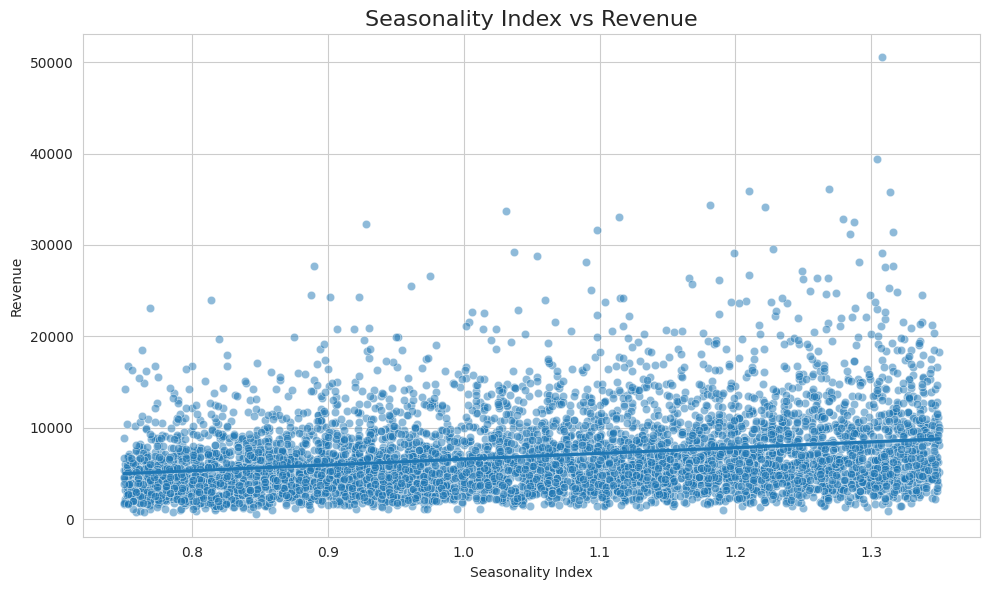

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Seasonality_Index',
    y='Revenue',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='Seasonality_Index',
    y='Revenue',
    scatter=False
)

plt.title(
    'Seasonality Index vs Revenue',
    fontsize=16
)

plt.xlabel('Seasonality Index')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

Marketing Spend Distribution

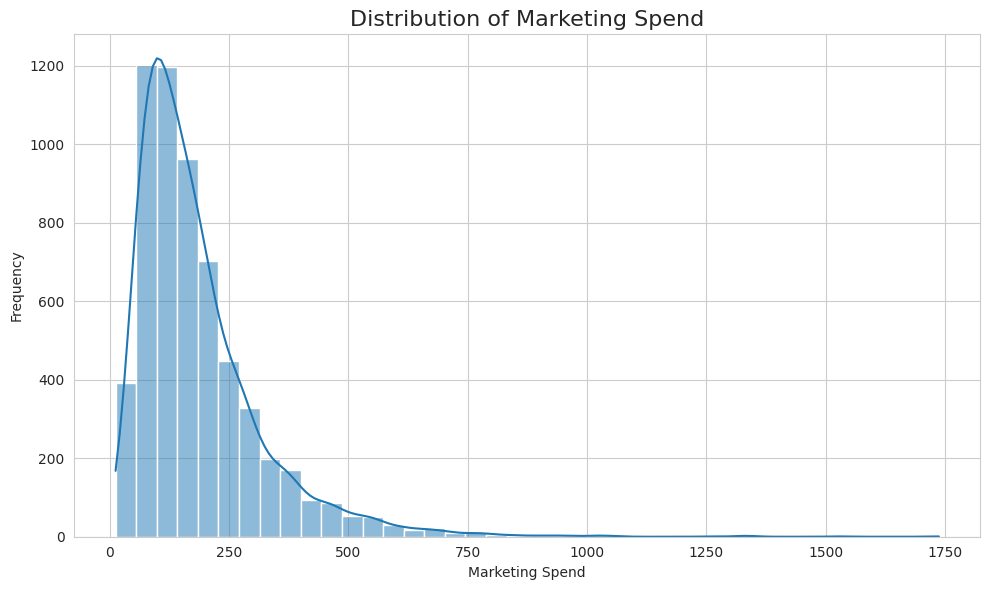

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Marketing_Spend',
    bins=40,
    kde=True
)

plt.title(
    'Distribution of Marketing Spend',
    fontsize=16
)

plt.xlabel('Marketing Spend')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Orders Distribution

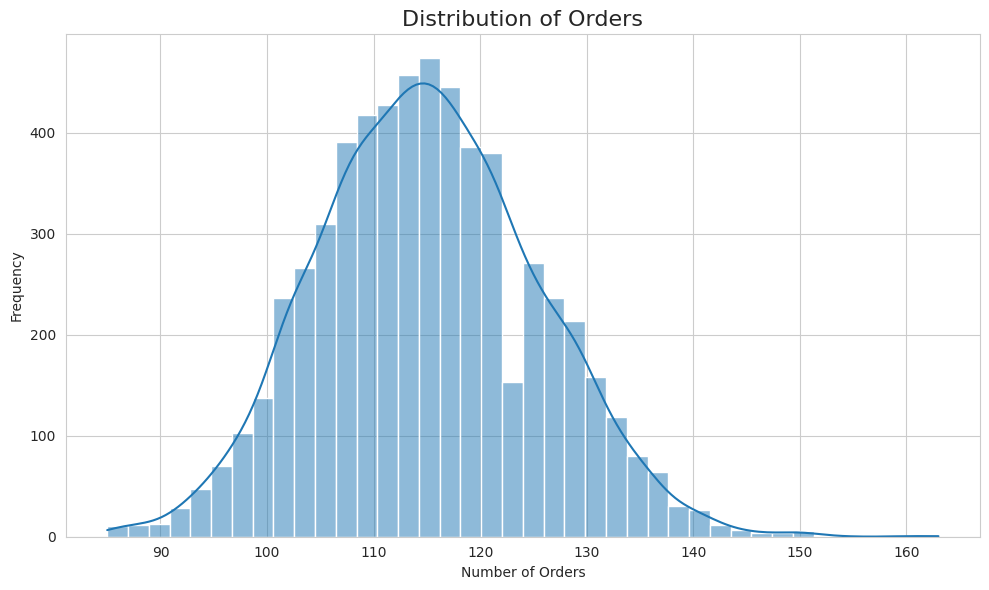

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Orders',
    bins=40,
    kde=True
)

plt.title(
    'Distribution of Orders',
    fontsize=16
)

plt.xlabel('Number of Orders')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Revenue vs Marketing Efficiency

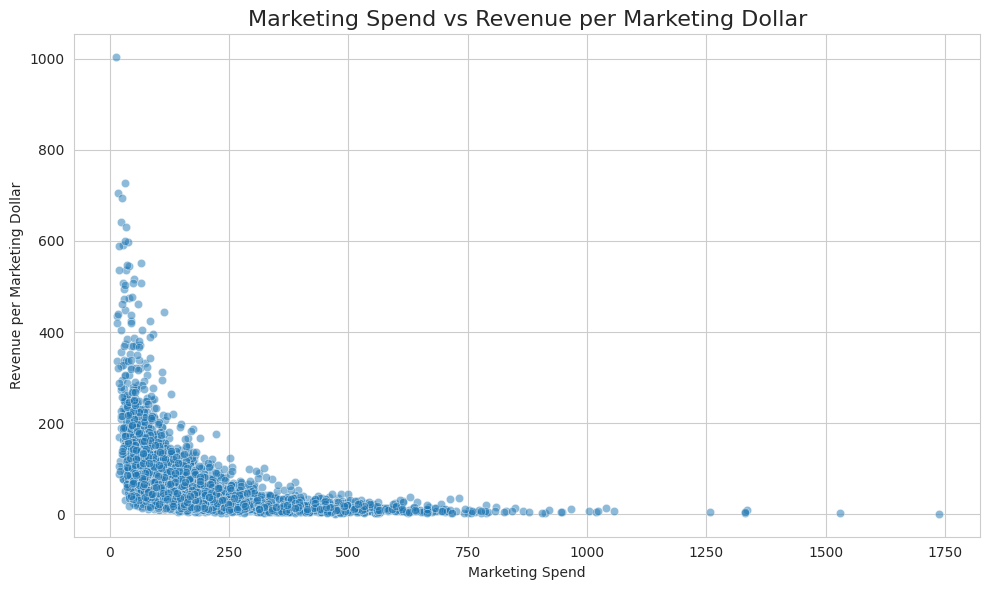

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Marketing_Spend',
    y='Revenue_Per_Marketing_Dollar',
    alpha=0.5
)

plt.title(
    'Marketing Spend vs Revenue per Marketing Dollar',
    fontsize=16
)

plt.xlabel('Marketing Spend')
plt.ylabel('Revenue per Marketing Dollar')

plt.tight_layout()
plt.show()

Revenue Per Order Distribution

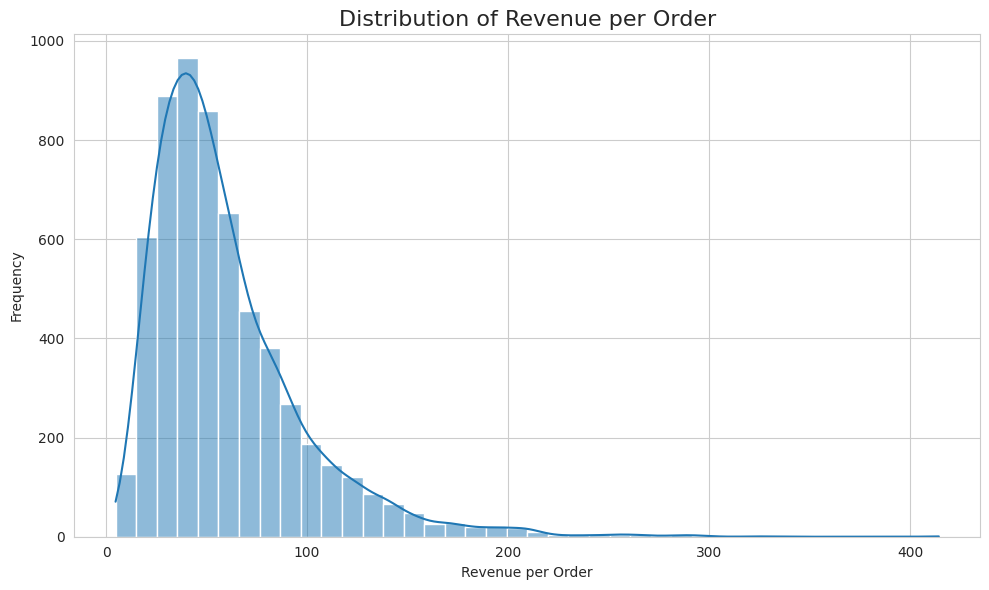

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Revenue_Per_Order',
    bins=40,
    kde=True
)

plt.title(
    'Distribution of Revenue per Order',
    fontsize=16
)

plt.xlabel('Revenue per Order')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Monthly Total Revenue

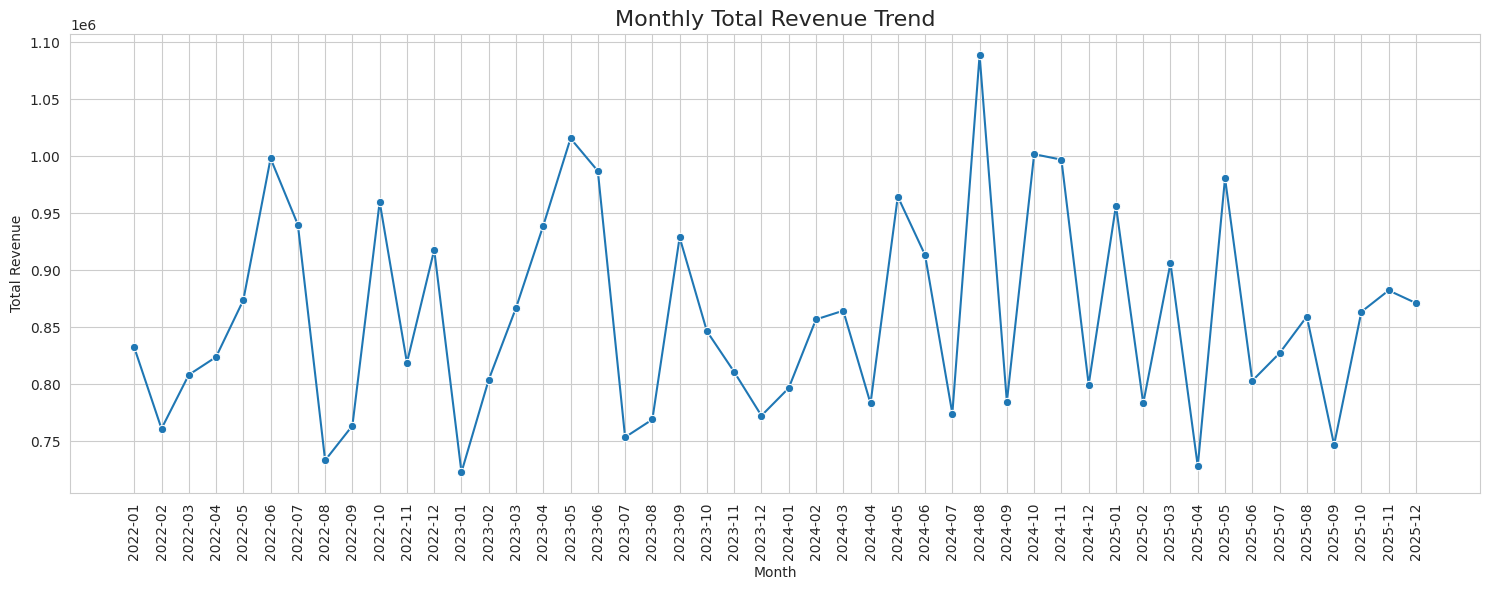

In [ ]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly_revenue,
    x=monthly_revenue.index,
    y='Total_Revenue',
    marker='o'
)

plt.title(
    'Monthly Total Revenue Trend',
    fontsize=16
)

plt.xlabel('Month')
plt.ylabel('Total Revenue')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Monthly Total Orders

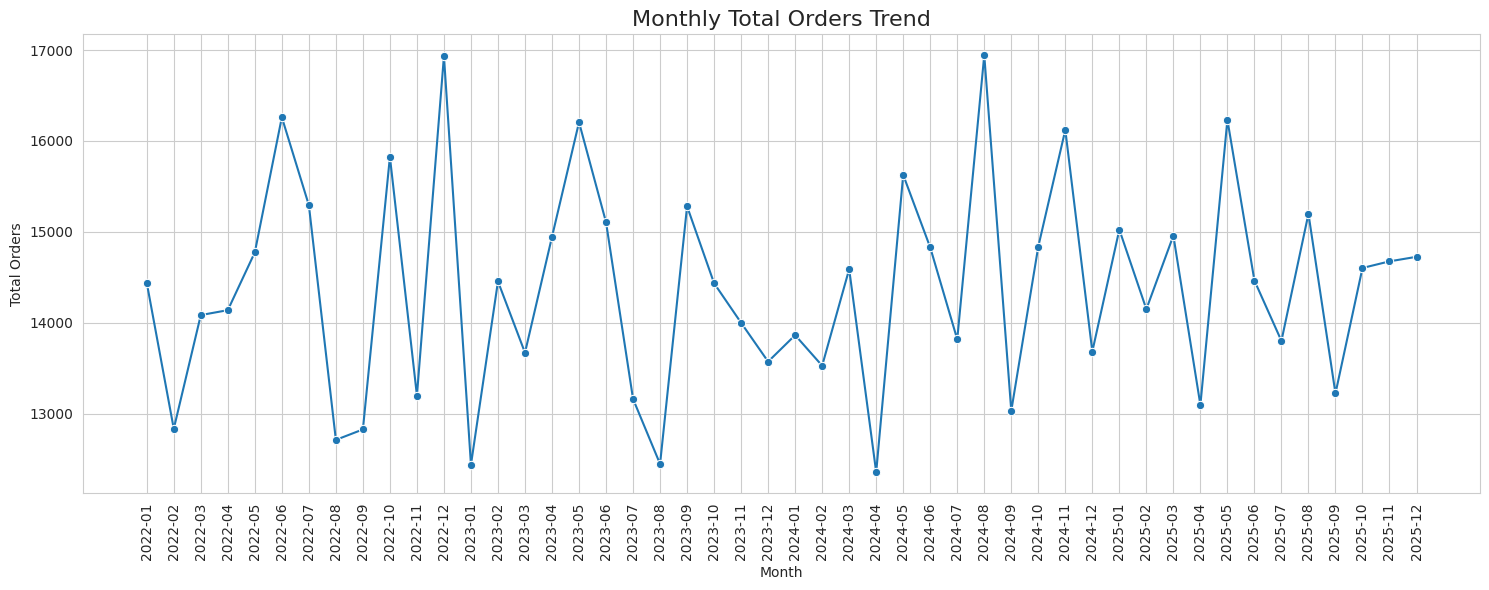

In [ ]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly_revenue,
    x=monthly_revenue.index,
    y='Total_Orders',
    marker='o'
)

plt.title(
    'Monthly Total Orders Trend',
    fontsize=16
)

plt.xlabel('Month')
plt.ylabel('Total Orders')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Marketing Spend and Revenue Over Time

In [ ]:
monthly_marketing = (
    df
    .groupby('Year_Month')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Total_Marketing_Spend=(
            'Marketing_Spend',
            'sum'
        )
    )
)

print(monthly_marketing.head())

            Total_Revenue  Total_Marketing_Spend
Year_Month                                      
2022-01       832240.0000             24350.6500
2022-02       760928.5900             18977.5700
2022-03       808167.7700             23643.2200
2022-04       823810.0800             22136.6800
2022-05       873685.0300             21940.0100


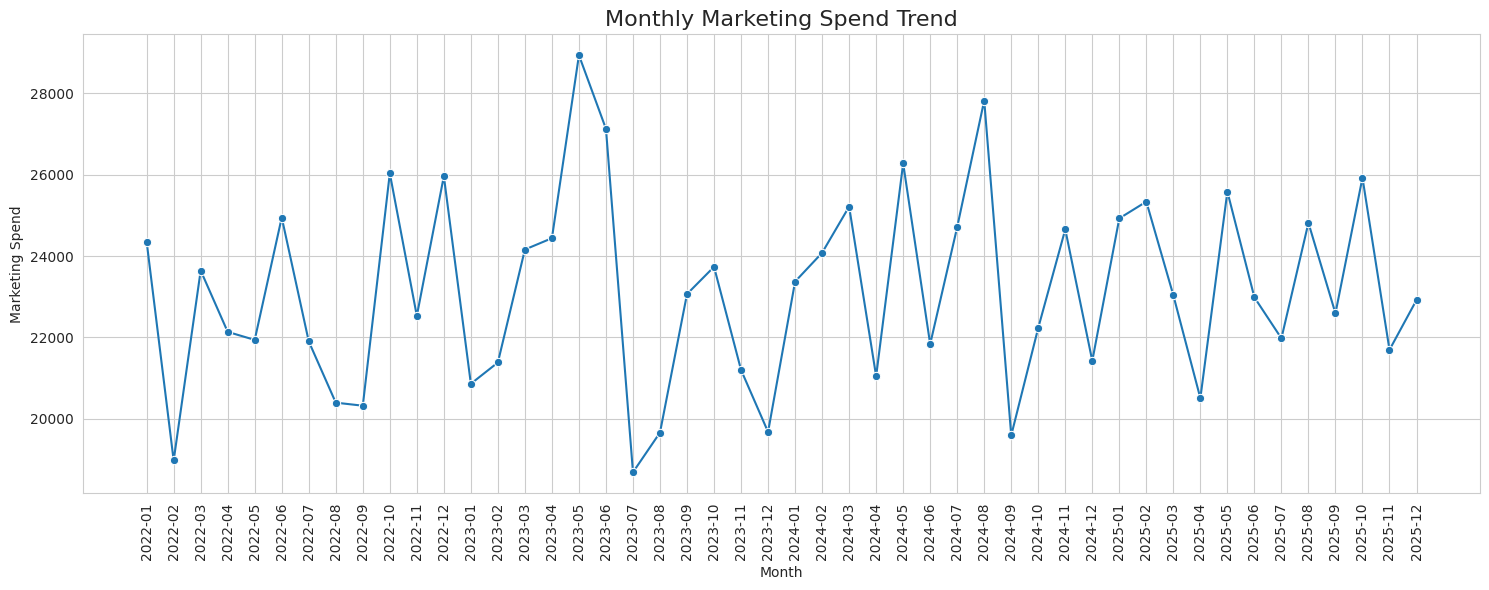

In [ ]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly_marketing,
    x=monthly_marketing.index,
    y='Total_Marketing_Spend',
    marker='o'
)

plt.title(
    'Monthly Marketing Spend Trend',
    fontsize=16
)

plt.xlabel('Month')
plt.ylabel('Marketing Spend')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

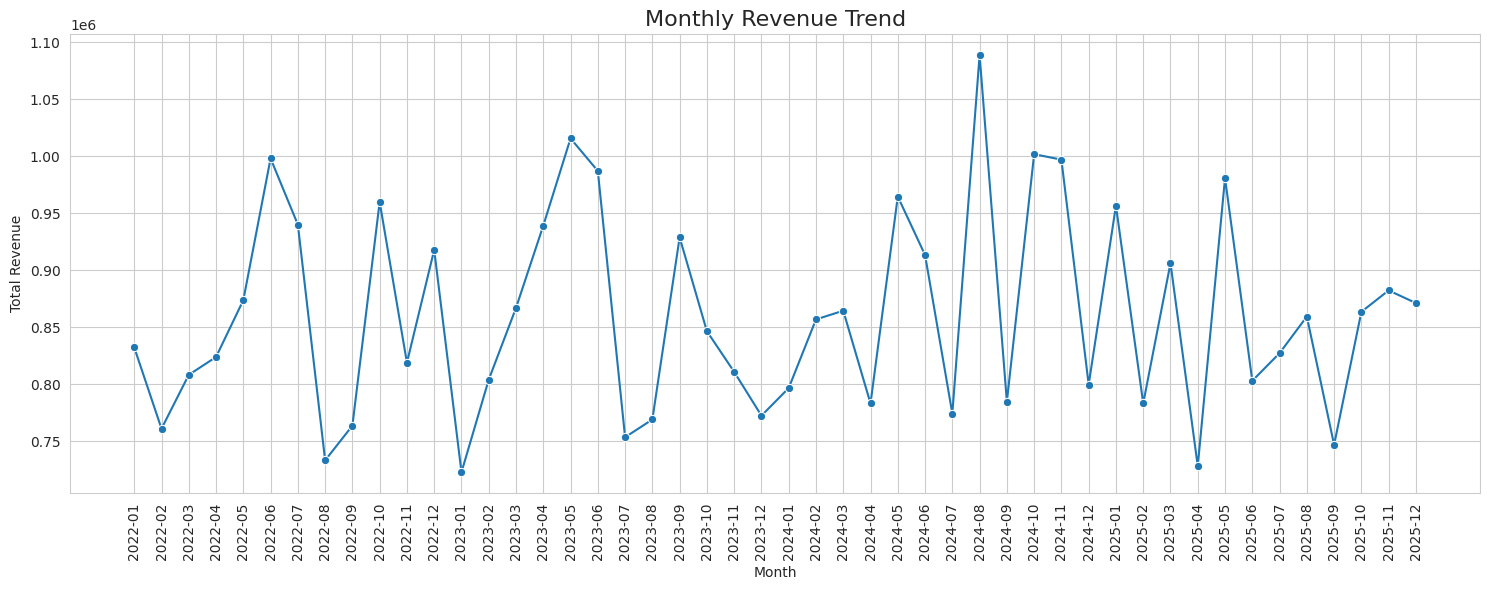

In [ ]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly_marketing,
    x=monthly_marketing.index,
    y='Total_Revenue',
    marker='o'
)

plt.title(
    'Monthly Revenue Trend',
    fontsize=16
)

plt.xlabel('Month')
plt.ylabel('Total Revenue')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Revenue Category vs Sales Channel

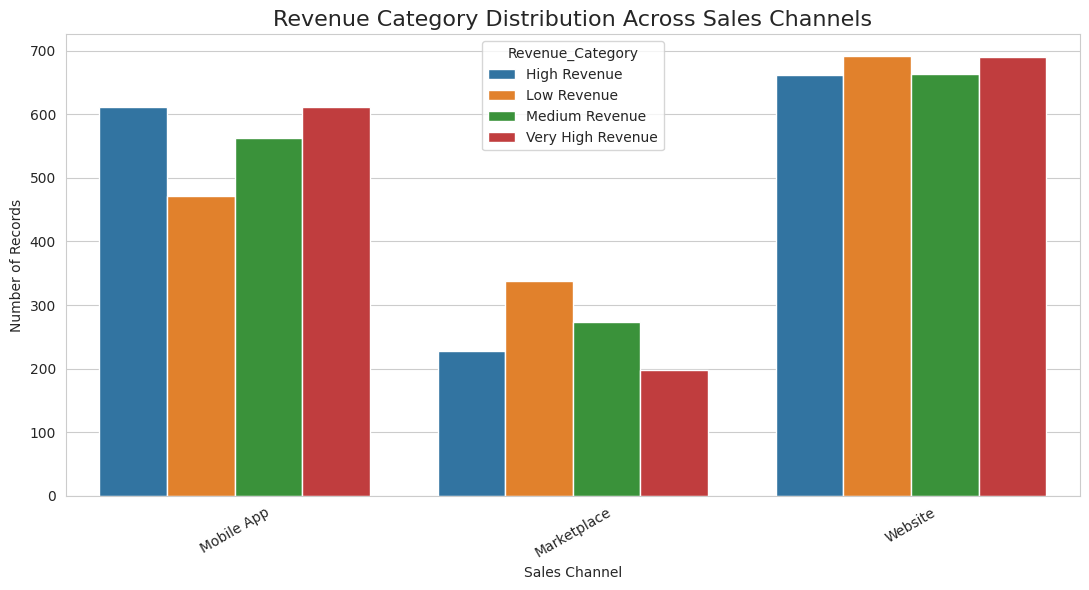

In [ ]:
plt.figure(figsize=(11, 6))

sns.countplot(
    data=df,
    x='Sales_Channel',
    hue='Revenue_Category'
)

plt.title(
    'Revenue Category Distribution Across Sales Channels',
    fontsize=16
)

plt.xlabel('Sales Channel')
plt.ylabel('Number of Records')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


In [ ]:
revenue_category_channel = pd.crosstab(
    df['Sales_Channel'],
    df['Revenue_Category']
)

print(revenue_category_channel)

Revenue_Category  High Revenue  Low Revenue  Medium Revenue  Very High Revenue
Sales_Channel                                                                 
Marketplace                227          337             274                198
Mobile App                 612          472             563                612
Website                    661          691             663                690


Marketing Spend vs Revenue per Marketing Dollar

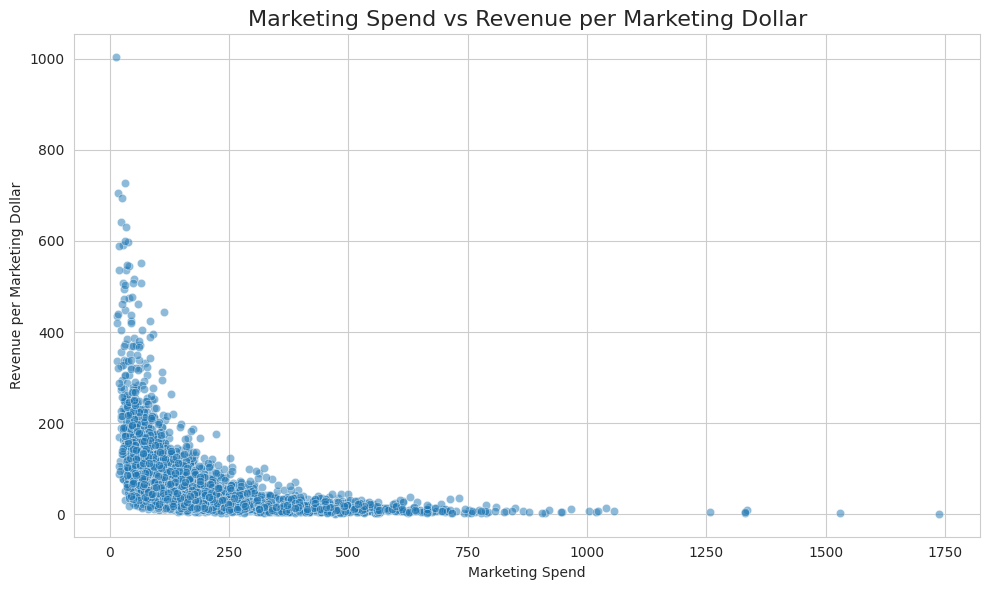

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Marketing_Spend',
    y='Revenue_Per_Marketing_Dollar',
    alpha=0.5
)

plt.title(
    'Marketing Spend vs Revenue per Marketing Dollar',
    fontsize=16
)

plt.xlabel('Marketing Spend')
plt.ylabel('Revenue per Marketing Dollar')

plt.tight_layout()
plt.show()

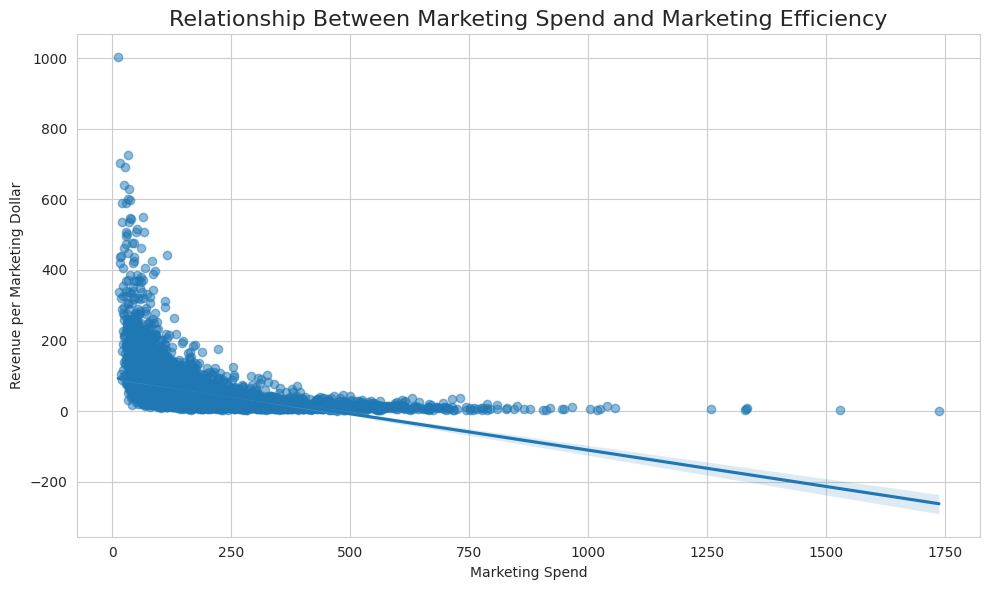

In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Marketing_Spend',
    y='Revenue_Per_Marketing_Dollar',
    scatter_kws={'alpha': 0.5}
)

plt.title(
    'Relationship Between Marketing Spend and Marketing Efficiency',
    fontsize=16
)

plt.xlabel('Marketing Spend')
plt.ylabel('Revenue per Marketing Dollar')

plt.tight_layout()
plt.show()

In [ ]:
marketing_efficiency_corr = (
    df[
        [
            'Marketing_Spend',
            'Revenue_Per_Marketing_Dollar'
        ]
    ]
    .corr()
)

print(marketing_efficiency_corr)

                              Marketing_Spend  Revenue_Per_Marketing_Dollar
Marketing_Spend                        1.0000                       -0.4309
Revenue_Per_Marketing_Dollar          -0.4309                        1.0000


Monthly Total Orders

In [ ]:
df['Year_Month'] = (
    df['Date']
    .dt.to_period('M')
    .astype(str)
)

In [ ]:
monthly_orders = (
    df
    .groupby('Year_Month')
    .agg(
        Total_Orders=('Orders', 'sum'),
        Average_Orders=('Orders', 'mean'),
        Total_Revenue=('Revenue', 'sum')
    )
)

print(monthly_orders)

            Total_Orders  Average_Orders  Total_Revenue
Year_Month                                             
2022-01            14439        115.5120    832240.0000
2022-02            12833        115.6126    760928.5900
2022-03            14084        113.5806    808167.7700
2022-04            14138        114.9431    823810.0800
2022-05            14774        115.4219    873685.0300
2022-06            16260        114.5070    998022.9400
2022-07            15293        114.9850    939933.7900
2022-08            12711        114.5135    733148.3400
2022-09            12826        116.6000    763564.7500
2022-10            15824        115.5036    959866.5800
2022-11            13199        115.7807    818815.8500
2022-12            16933        116.7793    917801.6500
2023-01            12438        114.1101    722715.5800
2023-02            14454        114.7143    803946.2100
2023-03            13670        114.8739    866901.9700
2023-04            14945        114.9615    9390

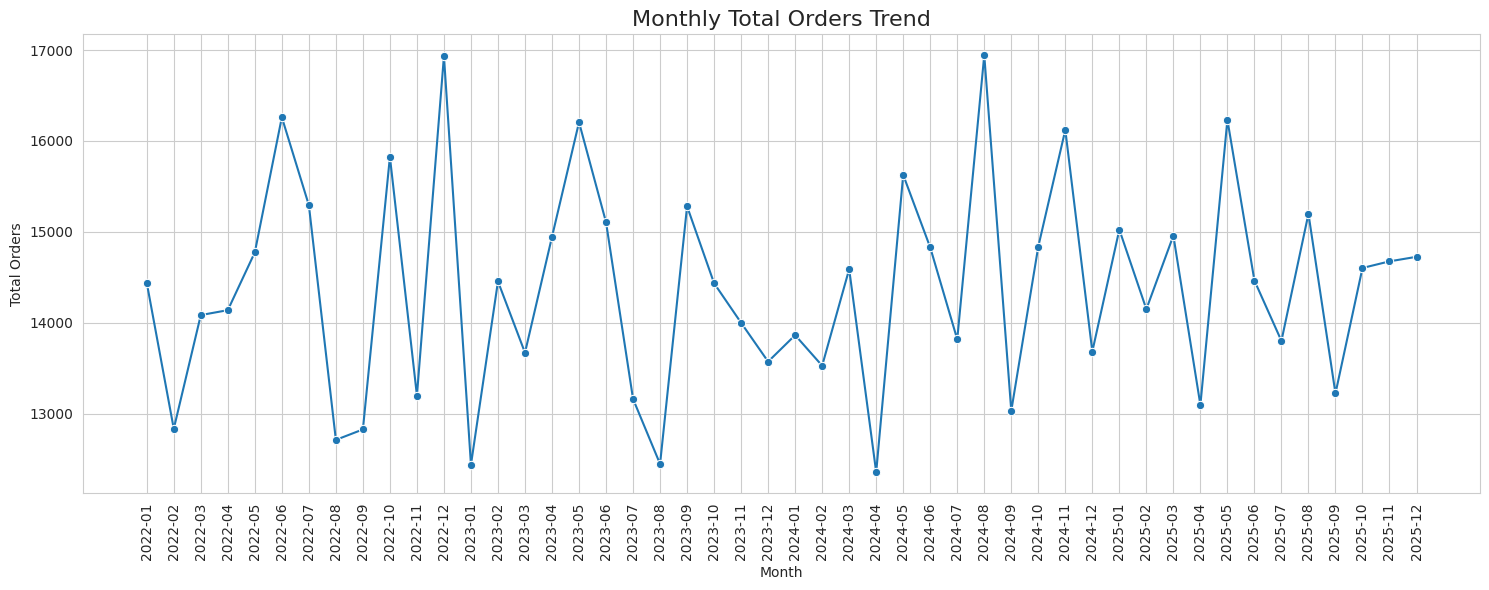

In [ ]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly_orders,
    x=monthly_orders.index,
    y='Total_Orders',
    marker='o'
)

plt.title(
    'Monthly Total Orders Trend',
    fontsize=16
)

plt.xlabel('Month')
plt.ylabel('Total Orders')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
monthly_orders['Order_Growth_Percent'] = (
    monthly_orders['Total_Orders']
    .pct_change()
    * 100
)

print(
    monthly_orders[
        [
            'Total_Orders',
            'Order_Growth_Percent'
        ]
    ]
)

            Total_Orders  Order_Growth_Percent
Year_Month                                    
2022-01            14439                   NaN
2022-02            12833              -11.1227
2022-03            14084                9.7483
2022-04            14138                0.3834
2022-05            14774                4.4985
2022-06            16260               10.0582
2022-07            15293               -5.9471
2022-08            12711              -16.8835
2022-09            12826                0.9047
2022-10            15824               23.3744
2022-11            13199              -16.5887
2022-12            16933               28.2900
2023-01            12438              -26.5458
2023-02            14454               16.2084
2023-03            13670               -5.4241
2023-04            14945                9.3270
2023-05            16205                8.4309
2023-06            15105               -6.7880
2023-07            13161              -12.8699
2023-08      

Correlation Heatmap

In [ ]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

In [ ]:
columns_to_exclude = [
    'Revenue_Per_Order',
    'Revenue_Per_Marketing_Dollar',
    'Revenue_Per_Visit',
    'Revenue_Per_Unique_Visitor',
    'Revenue_Gap'
]

correlation_data = df[
    numeric_columns
].drop(
    columns=columns_to_exclude,
    errors='ignore'
)

In [ ]:
correlation_matrix = (
    correlation_data
    .corr()
)

print(correlation_matrix)

                               Marketing_Spend  Website_Visits  \
Marketing_Spend                         1.0000          0.0036   
Website_Visits                          0.0036          1.0000   
Unique_Visitors                        -0.0067          0.0106   
Conversion_Rate                        -0.0001          0.0018   
Average_Order_Value                     0.0072         -0.0024   
Orders                                 -0.0029          0.0039   
Returning_Customer_Rate                -0.0142         -0.0024   
Discount_Rate                          -0.0260         -0.0034   
Ad_Clicks                               0.0233          0.0044   
Email_Campaigns                        -0.0068          0.0129   
Mobile_Traffic_Percent                 -0.0051         -0.0052   
Customer_Rating                        -0.0080         -0.0003   
Return_Rate                             0.0022          0.0006   
Shipping_Delay_Days                     0.0017         -0.0061   
Product_Av

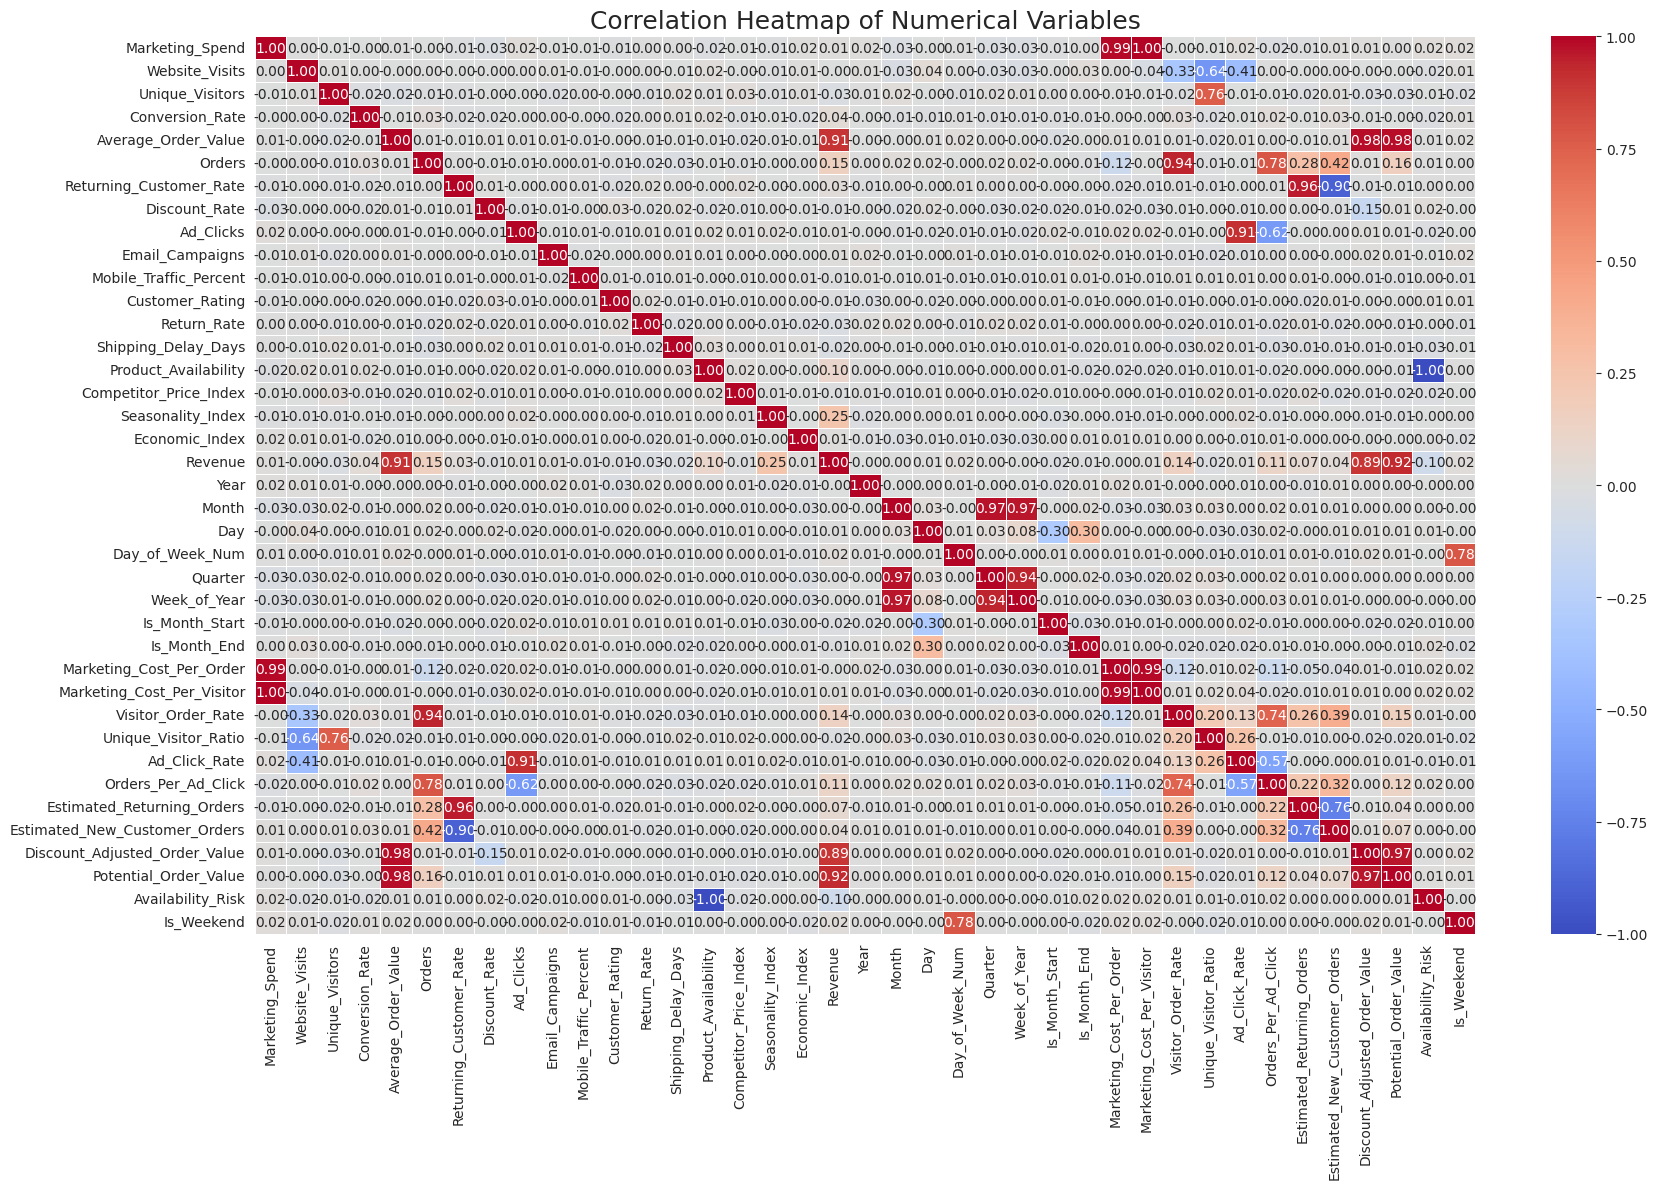

In [ ]:
plt.figure(figsize=(18, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title(
    'Correlation Heatmap of Numerical Variables',
    fontsize=18
)

plt.tight_layout()
plt.show()

In [ ]:
revenue_correlations = (
    correlation_matrix['Revenue']
    .drop('Revenue')
    .sort_values(
        ascending=False
    )
)

print(
    "Positive correlations with Revenue:"
)

print(
    revenue_correlations[
        revenue_correlations > 0
    ]
)

Positive correlations with Revenue:
Potential_Order_Value           0.9227
Average_Order_Value             0.9062
Discount_Adjusted_Order_Value   0.8932
Seasonality_Index               0.2473
Orders                          0.1514
Visitor_Order_Rate              0.1433
Orders_Per_Ad_Click             0.1122
Product_Availability            0.1011
Estimated_Returning_Orders      0.0700
Conversion_Rate                 0.0442
Estimated_New_Customer_Orders   0.0367
Returning_Customer_Rate         0.0285
Day_of_Week_Num                 0.0200
Is_Weekend                      0.0180
Marketing_Cost_Per_Visitor      0.0142
Marketing_Spend                 0.0133
Email_Campaigns                 0.0124
Ad_Click_Rate                   0.0118
Ad_Clicks                       0.0116
Economic_Index                  0.0097
Day                             0.0057
Quarter                         0.0018
Month                           0.0008
Name: Revenue, dtype: float64


In [ ]:
print(
    "\nNegative correlations with Revenue:"
)

print(
    revenue_correlations[
        revenue_correlations < 0
    ]
)


Negative correlations with Revenue:
Year                       -0.0000
Week_of_Year               -0.0005
Marketing_Cost_Per_Order   -0.0024
Website_Visits             -0.0030
Discount_Rate              -0.0078
Customer_Rating            -0.0081
Mobile_Traffic_Percent     -0.0092
Is_Month_End               -0.0115
Competitor_Price_Index     -0.0146
Unique_Visitor_Ratio       -0.0181
Is_Month_Start             -0.0198
Shipping_Delay_Days        -0.0236
Unique_Visitors            -0.0251
Return_Rate                -0.0262
Availability_Risk          -0.1011
Name: Revenue, dtype: float64


In [ ]:
absolute_revenue_correlations = (
    revenue_correlations
    .abs()
    .sort_values(
        ascending=False
    )
)

print(
    "Strongest relationships with Revenue:"
)

print(
    absolute_revenue_correlations.head(15)
)

Strongest relationships with Revenue:
Potential_Order_Value           0.9227
Average_Order_Value             0.9062
Discount_Adjusted_Order_Value   0.8932
Seasonality_Index               0.2473
Orders                          0.1514
Visitor_Order_Rate              0.1433
Orders_Per_Ad_Click             0.1122
Availability_Risk               0.1011
Product_Availability            0.1011
Estimated_Returning_Orders      0.0700
Conversion_Rate                 0.0442
Estimated_New_Customer_Orders   0.0367
Returning_Customer_Rate         0.0285
Return_Rate                     0.0262
Unique_Visitors                 0.0251
Name: Revenue, dtype: float64
